In [1]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text
import torch 
warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
from atse_viz import *
import gffutils

db_file_mouse = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/genomes/lr_GRCm38.db"
db_mouse = gffutils.FeatureDB(db_file_mouse, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"
GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_scvi_model_latent_20_20000_2025-10-09.h5ad"

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
print(f"Renaming mouse.id to donor_id in splice_adata.obs")
# Update gene annotations
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
rbps = rbps["mouse_gene_name"]

Done reading the ge_adata with scVI...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Renaming mouse.id to donor_id in splice_adata.obs


In [ ]:
original_splice_adata = f"{BASE_DIR}/MODEL_INPUT/102025/model_ready_aligned_splicing_data_20251009_024406.h5ad"
full_splice_adata = ad.read_h5ad(original_splice_adata)
full_splice_adata.obs_names
MAX_JUNCTIONS = 5
full_splice_adata = full_splice_adata[:, full_splice_adata.var["num_junctions"] <= MAX_JUNCTIONS].copy()
full_splice_adata.var["junction_id_index"] = np.arange(full_splice_adata.shape[1])
full_splice_adata.shape

Index(['A10_B000120', 'A10_B000126', 'A10_B000127', 'A10_B000166',
       'A10_B000169', 'A10_B000170', 'A10_B000176', 'A10_B000229',
       'A10_B000232', 'A10_B000246',
       ...
       'US-1250275_E2_S77', 'US-1250275_E2_S78', 'US-1250275_E2_S82',
       'US-1250275_E2_S83', 'US-1250275_E2_S85', 'US-1250275_E2_S86',
       'US-1250275_E2_S87', 'US-1250275_E2_S88', 'US-1250275_E2_S89',
       'US-1250275_E2_S90'],
      dtype='object', name='cell_id', length=142315)

In [5]:
cell_types_summary = full_splice_adata.obs[["cell_ontology_class", "tissue"]].value_counts()
cell_types_summary = pd.DataFrame(cell_types_summary)
cell_types_summary.to_csv("cell_types_summary.csv")

df = pd.read_csv("cell_types_summary.csv")
import pandas as pd

# 1. Temporarily set the option to display a very large number of rows (or None for all)
# We'll set it to 500, which should be plenty for your 154 groups.
pd.set_option('display.max_rows', 500) 
df["cell_ontology_class"].value_counts() #--> manually curate these into more easy to read cell type labels (with help from Gemini)

cell_ontology_class
T cell                                                 13
macrophage                                             12
endothelial cell                                       11
B cell                                                 11
NK cell                                                 8
CD8-positive, alpha-beta T cell                         7
CD4-positive, alpha-beta T cell                         7
epithelial cell                                         5
mesenchymal stem cell of adipose                        4
myeloid cell                                            4
granulocyte                                             3
fibroblast                                              3
mature NK T cell                                        3
leukocyte                                               2
ciliated columnar cell of tracheobronchial tree         2
neutrophil                                              2
mesenchymal stem cell                               

In [6]:
# read in manually curated cell type mapping
cell_type_mapping = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/cell_type_annotation_manual_mouse.tsv", sep="\t")
# rename cell_type_mapping Medium Cell Type and Broad Cell Type columns to medium_cell_type and broad_cell_type
cell_type_mapping.rename(columns={"Medium Cell Type": "medium_cell_type", "Broad Cell Type": "broad_cell_type"}, inplace=True)
cell_type_mapping.head()

,cell_ontology_class,Count,medium_cell_type,broad_cell_type
0,T cell,13,T Cell Lineage,Immune
1,macrophage,12,Phagocytic/APCs,Immune
2,B cell,11,B Cell Lineage,Immune
3,endothelial cell,11,Endothelial (General),Endothelial
4,NK cell,8,NK/Innate Lymphoid,Immune


In [7]:
# remove old medium_cell_type and broad_cell_type columns from full_splice_adata.obs
full_splice_adata.obs.drop(columns=["medium_cell_type", "broad_cell_type"], inplace=True)
# add new medium_cell_type and broad_cell_type columns from cell_type_mapping
full_splice_adata.obs["medium_cell_type"] = full_splice_adata.obs["cell_ontology_class"].map(cell_type_mapping.set_index("cell_ontology_class")["medium_cell_type"])
full_splice_adata.obs["broad_cell_type"] = full_splice_adata.obs["cell_ontology_class"].map(cell_type_mapping.set_index("cell_ontology_class")["broad_cell_type"])

In [8]:
full_splice_adata.obs

,cell_id_index,age,cell_ontology_class,mouse.id,sex,subtissue,tissue,dataset,cell_name,cell_id,...,specific_cell_type,seqtech,library_size,total_junction_reads,annotated_junction_reads,unannotated_junction_reads,n_detected_annotated_junctions,n_detected_unannotated_junctions,medium_cell_type,broad_cell_type
cell_id,,,,,,,,,,,,,,,,,,,,,
A10_B000120,0,18m,basal epithelial cell of tracheobronchial tree,18_47_F,F,NaN,Trachea,TMS,A10_B000120,A10_B000120,...,Tracheobronchial basal epithelial cell,single_cell,6797,6061,5897,164,406,16,Epithelial (Airway),Epithelial
A10_B000126,1,3m,bulge keratinocyte,3_39_F,F,Telogen,Skin,TMS,A10_B000126,A10_B000126,...,Bulge keratinocyte,single_cell,33982,30890,30304,586,1661,46,Epithelial (Skin),Epithelial
A10_B000127,2,3m,myeloid cell,3_38_F,F,Fat,SCAT,TMS,A10_B000127,A10_B000127,...,Myeloid cell,single_cell,17044,15105,14744,361,363,31,Myeloid Lineage,Immune
A10_B000166,3,3m,basal cell,3_56_F,F,Mammary_Gland,Mammary_Gland,TMS,A10_B000166,A10_B000166,...,Basal cell,single_cell,279337,254958,249373,5585,4246,164,Epithelial (General),Epithelial
A10_B000169,4,18m,endothelial cell of coronary artery,18_53_M,M,RV,Heart,TMS,A10_B000169,A10_B000169,...,Coronary endothelial cell,single_cell,17794,15666,15545,121,350,4,Endothelial (Vascular),Endothelial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US-1250275_E2_S86,142310,2m,197_L5 IT CTX,184750,F,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S86,US-1250275_E2_S86,...,Layer 5 excitatory neuron,single_nuclei,53587,48275,45749,2526,9393,240,Excitatory Neurons (Cortical),Neuron
US-1250275_E2_S87,142311,2m,204_L5/6 IT CTX,184756,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S87,US-1250275_E2_S87,...,Layer 5 excitatory neuron,single_nuclei,44150,39687,36238,3449,8268,218,Excitatory Neurons (Cortical),Neuron
US-1250275_E2_S88,142312,2m,257_L5 PT CTX,185199,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S88,US-1250275_E2_S88,...,Layer 5 excitatory neuron,single_nuclei,48161,42726,39975,2751,10177,232,Excitatory Neurons (Cortical),Neuron


In [9]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-11-13"
MODEL_ANALYSIS_DATE = "2025-11-19"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.gz"

# Main data files from downstream analysis of model 
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

In [10]:
# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)

# remove old medium_cell_type and broad_cell_type columns from full_splice_adata.obs
splice_adata.obs.drop(columns=["medium_cell_type", "broad_cell_type"], inplace=True)
# add new medium_cell_type and broad_cell_type columns from cell_type_mapping
splice_adata.obs["medium_cell_type"] = splice_adata.obs["cell_ontology_class"].map(cell_type_mapping.set_index("cell_ontology_class")["medium_cell_type"])
splice_adata.obs["broad_cell_type"] = splice_adata.obs["cell_ontology_class"].map(cell_type_mapping.set_index("cell_ontology_class")["broad_cell_type"])

MAX_JUNCTIONS = 5
splice_adata = splice_adata[:, splice_adata.var["num_junctions"] <= MAX_JUNCTIONS].copy()
splice_adata.var["junction_id_index"] = np.arange(splice_adata.shape[1])

assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

# print how many cells are in splice_adata
print(f"There are {len(splice_adata.obs)} cells in splice_adata")

# print how many cells are in ge_adata
print(f"There are {len(ge_adata.obs)} cells in ge_adata")

Loading data for param_id 0 from 2025-11-13
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/data
There are 142315 cells in splice_adata
There are 142315 cells in ge_adata


In [11]:
pi = np.load(PI_VALUES_PATH)
leaflet_model = load_model(MODEL_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)

Loading model to device: cpu


In [12]:
splice_adata.obs_names = splice_adata.obs["cell_id"]

In [13]:
print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")

Loaded splice_adata: (142315, 70102)
Loaded PI values: (20,)


In [14]:
# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs


In [15]:
splice_adata.obsm["X_PHI"].shape

(142315, 20)

### Add module labels to cell types 

In [16]:
# Always assert after creation or reuse
assert all(splice_adata.obs_names == ge_adata.obs_names)
splice_adata.obs["total_counts"] = ge_adata.obs["total_counts"]

## Rename factors to be in order that matches PI

In [17]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)

Sorted pi values with original factor indices:
Rank 1: Factor 1 → PI = 0.0706
Rank 2: Factor 9 → PI = 0.0682
Rank 3: Factor 13 → PI = 0.0628
Rank 4: Factor 14 → PI = 0.0597
Rank 5: Factor 19 → PI = 0.0528
Rank 6: Factor 2 → PI = 0.0506
Rank 7: Factor 0 → PI = 0.0494
Rank 8: Factor 11 → PI = 0.0488
Rank 9: Factor 7 → PI = 0.0474
Rank 10: Factor 5 → PI = 0.0465
Rank 11: Factor 10 → PI = 0.0460
Rank 12: Factor 8 → PI = 0.0459
Rank 13: Factor 4 → PI = 0.0456
Rank 14: Factor 12 → PI = 0.0455
Rank 15: Factor 6 → PI = 0.0454
Rank 16: Factor 17 → PI = 0.0440
Rank 17: Factor 3 → PI = 0.0440
Rank 18: Factor 18 → PI = 0.0431
Rank 19: Factor 15 → PI = 0.0420
Rank 20: Factor 16 → PI = 0.0417
{1: 0, 9: 1, 13: 2, 14: 3, 19: 4, 2: 5, 0: 6, 11: 7, 7: 8, 5: 9, 10: 10, 8: 11, 4: 12, 12: 13, 6: 14, 17: 15, 3: 16, 18: 17, 15: 18, 16: 19}


In [18]:
splice_adata.obs

,cell_id_index,age,cell_ontology_class,donor_id,sex,subtissue,tissue,dataset,cell_name,cell_id,...,SP_11,SP_12,SP_13,SP_14,SP_15,SP_16,SP_17,SP_18,SP_19,SP_20
cell_id,,,,,,,,,,,,,,,,,,,,,
A10_B000120,0,18m,basal epithelial cell of tracheobronchial tree,18_47_F,female,NaN,Trachea,TMS,A10_B000120,A10_B000120,...,0.001004,0.036936,0.004467,0.007936,0.001129,0.001057,0.001042,0.004361,0.000568,0.001831
A10_B000126,1,3m,bulge keratinocyte,3_39_F,female,Telogen,Skin,TMS,A10_B000126,A10_B000126,...,0.000330,0.000857,0.001971,0.029358,0.000401,0.000236,0.000557,0.000394,0.000341,0.000157
A10_B000127,2,3m,myeloid cell,3_38_F,female,Fat,SCAT,TMS,A10_B000127,A10_B000127,...,0.000728,0.010527,0.001510,0.000752,0.000962,0.000285,0.001365,0.000475,0.000276,0.000418
A10_B000166,3,3m,basal cell,3_56_F,female,Mammary_Gland,Mammary_Gland,TMS,A10_B000166,A10_B000166,...,0.000092,0.000569,0.002294,0.011650,0.000473,0.000096,0.014588,0.000505,0.000099,0.000126
A10_B000169,4,18m,endothelial cell of coronary artery,18_53_M,male,RV,Heart,TMS,A10_B000169,A10_B000169,...,0.000345,0.000867,0.002737,0.000975,0.000555,0.000510,0.000278,0.000632,0.000301,0.000273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US-1250275_E2_S86,142310,2m,197_L5 IT CTX,184750,female,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S86,US-1250275_E2_S86,...,0.058734,0.001177,0.000660,0.001044,0.017001,0.003374,0.000363,0.001665,0.009833,0.001177
US-1250275_E2_S87,142311,2m,204_L5/6 IT CTX,184756,male,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S87,US-1250275_E2_S87,...,0.031065,0.001277,0.000527,0.004193,0.004207,0.025079,0.001535,0.002277,0.033761,0.022413
US-1250275_E2_S88,142312,2m,257_L5 PT CTX,185199,male,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S88,US-1250275_E2_S88,...,0.034542,0.001582,0.000968,0.000702,0.005240,0.041733,0.002170,0.001721,0.002497,0.003153


In [19]:
# --- Setup and Data Loading (Same as before) ---
psis_loc = leaflet_model["psis_loc"] # Shape: [K, J] -> [20, 70102]
psis_scale = leaflet_model["psis_scale"] # Shape: [K, J] -> [20, 70102]
S = 100 # Number of samples (S)
K = psis_loc.shape[0] # Number of factors (K=20)
J = psis_loc.shape[1] # Number of junctions (J=70102)

print(f"Sampling Parameters: S={S}, K={K}, J={J}")

# --- 1. Full Factorial Sampling (Unconstrained Space) ---

# Expand dimensions of psis_loc and psis_scale: [K, J] -> [K, J, 1]
# This makes them broadcastable for the S=100 samples.
loc_expanded = psis_loc[:, np.newaxis, :] # Shape [20, 1, 70102]
scale_expanded = psis_scale[:, np.newaxis, :] # Shape [20, 1, 70102]

# Use np.random.normal to sample from ALL K*J distributions at once.
# The size argument ensures we get S samples for each (K, J) pair.
# Resulting shape: [K, S, J]
psi_samples_logit_K_S_J = np.random.normal(
    loc=loc_expanded, 
    scale=scale_expanded, 
    size=(K, S, J)
)

# --- 2. Convert to PSI (0-1 Range) ---

# Apply the inverse logit (Sigmoid) function
psi_samples_psi_K_S_J = 1 / (1 + np.exp(-psi_samples_logit_K_S_J))


# --- 3. Reorder to [S, K, J] and Finalize ---

# Transpose the array to the required shape [S, K, J]
psi_samples_psi_S_K_J = np.transpose(psi_samples_psi_K_S_J, (1, 0, 2))

# Convert to torch.Tensor as required by the compute_psi_effect_size function
psi_samples_torch = torch.from_numpy(psi_samples_psi_S_K_J).float()


# --- 4. Add to Model Dictionary ---

leaflet_model["psi_samples"] = psi_samples_torch

print(f"\n✅ Finished processing and sampling in [S, K, J] format.")
print(f"   Key 'psi_samples' added to leaflet_model.")
print(f"   Shape of final samples (torch.Tensor): {leaflet_model['psi_samples'].shape}")
print(f"   Range check (min/max): {np.min(psi_samples_psi_S_K_J):.4f} / {np.max(psi_samples_psi_S_K_J):.4f}")

Sampling Parameters: S=100, K=20, J=70102

✅ Finished processing and sampling in [S, K, J] format.
   Key 'psi_samples' added to leaflet_model.
   Shape of final samples (torch.Tensor): torch.Size([100, 20, 70102])
   Range check (min/max): 0.0000 / 1.0000


In [20]:
leaflet_model["psi_samples"].shape

torch.Size([100, 20, 70102])

In [21]:
# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

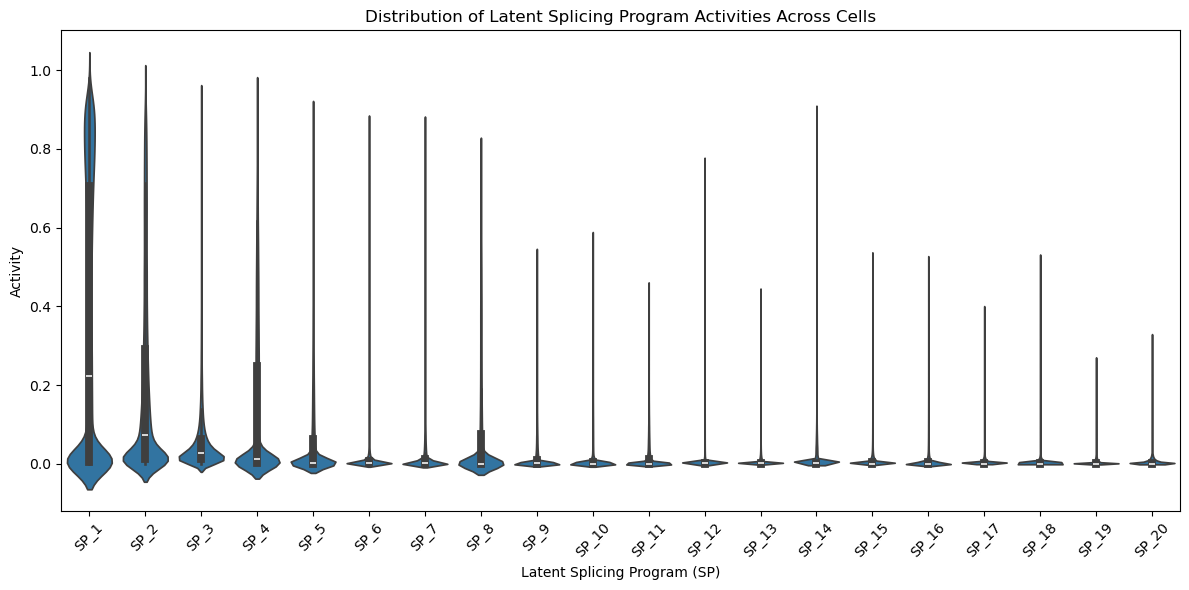

In [22]:
# Extract X_PHI matrix and convert to DataFrame
phi = pd.DataFrame(
    splice_adata.obsm["X_PHI"],
    index=splice_adata.obs["cell_id"]
)
phi.columns = [f"SP_{i+1}" for i in range(phi.shape[1])]

phi_long = phi.reset_index().melt(id_vars="cell_id", var_name="Splicing Program", value_name="Activity")

# Plot
plt.figure(figsize=(12, 6))  # Adjust width as needed
sns.violinplot(data=phi_long, x="Splicing Program", y="Activity", inner="box", scale="width")
plt.xticks(rotation=45)
plt.title("Distribution of Latent Splicing Program Activities Across Cells")
plt.xlabel("Latent Splicing Program (SP)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

In [23]:
# Clean up Broad Cell Type column
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
splice_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]

# Update ge_adata.obs to match 
ge_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
ge_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
ge_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]
ge_adata.obs["age_group"] = splice_adata.obs["age_group"]

assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [24]:
# Setup
phi_matrix = splice_adata.obsm["X_PHI"]
factor_names = [f"SP_{i+1}" for i in range(phi_matrix.shape[1])]

In [25]:
# 1. Update Astrocytes to Brain_Non-Myeloid
splice_adata.obs.loc[
    splice_adata.obs["medium_cell_type"] == "Glial (Astrocyte)",
    "tissue"
] = "Brain_Non-Myeloid"

# 2. Update Oligodendrocytes to Brain_Non-Myeloid
splice_adata.obs.loc[
    splice_adata.obs["medium_cell_type"] == "Glial (Oligodendrocyte)",
    "tissue"
] = "Brain_Non-Myeloid"

In [26]:
# Add our cell type tissue column 
if 'tissue' in splice_adata.obs.columns and 'medium_cell_type' in splice_adata.obs.columns:
    splice_adata.obs['tissue_celltype'] = (
        splice_adata.obs['tissue'].astype(str) + '_' +
        splice_adata.obs['medium_cell_type'].astype(str)
    )
print(f"\nCreated 'tissue_celltype' with {splice_adata.obs['tissue_celltype'].nunique()} combinations")


Created 'tissue_celltype' with 165 combinations


In [35]:
splice_adata.obs.iloc[1]

cell_id_index                                            1
age                                                     3m
cell_ontology_class                     bulge keratinocyte
donor_id                                            3_39_F
sex                                                 female
subtissue                                          Telogen
tissue                                                Skin
dataset                                                TMS
cell_name                                      A10_B000126
cell_id                                        A10_B000126
cell_clean                                     A10_B000126
specific_cell_type                      Bulge keratinocyte
seqtech                                        single_cell
library_size                                         33982
total_junction_reads                                 30890
annotated_junction_reads                             30304
unannotated_junction_reads                             5

In [27]:
!pwd

/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/NatureAging_PLOTTING_MOUSE


In [36]:
splice_adata.obs[["cell_id", "cell_name", "cell_ontology_class", "broad_cell_type", "medium_cell_type", "tissue", "tissue_celltype"]].drop_duplicates()

,cell_id,cell_name,cell_ontology_class,broad_cell_type,medium_cell_type,tissue,tissue_celltype
cell_id,,,,,,,
A10_B000120,A10_B000120,A10_B000120,basal epithelial cell of tracheobronchial tree,Epithelial,Epithelial (Airway),Trachea,Trachea_Epithelial (Airway)
A10_B000126,A10_B000126,A10_B000126,bulge keratinocyte,Epithelial,Epithelial (Skin),Skin,Skin_Epithelial (Skin)
A10_B000127,A10_B000127,A10_B000127,myeloid cell,Immune,Myeloid Lineage,SCAT,SCAT_Myeloid Lineage
A10_B000166,A10_B000166,A10_B000166,basal cell,Epithelial,Epithelial (General),Mammary_Gland,Mammary_Gland_Epithelial (General)
A10_B000169,A10_B000169,A10_B000169,endothelial cell of coronary artery,Endothelial,Endothelial (Vascular),Heart,Heart_Endothelial (Vascular)
...,...,...,...,...,...,...,...
US-1250275_E2_S86,US-1250275_E2_S86,US-1250275_E2_S86,197_L5 IT CTX,Neuron,Excitatory Neurons (Cortical),Brain_Non-Myeloid,Brain_Non-Myeloid_Excitatory Neurons (Cortical)
US-1250275_E2_S87,US-1250275_E2_S87,US-1250275_E2_S87,204_L5/6 IT CTX,Neuron,Excitatory Neurons (Cortical),Brain_Non-Myeloid,Brain_Non-Myeloid_Excitatory Neurons (Cortical)
US-1250275_E2_S88,US-1250275_E2_S88,US-1250275_E2_S88,257_L5 PT CTX,Neuron,Excitatory Neurons (Cortical),Brain_Non-Myeloid,Brain_Non-Myeloid_Excitatory Neurons (Cortical)


In [37]:
splice_adata.obs[["cell_id", "cell_name", "cell_ontology_class", "broad_cell_type", "medium_cell_type", "tissue", "tissue_celltype"]].drop_duplicates().to_csv("tissue_celltype_mapping.csv", index=False)

In [29]:
splice_adata.obs[["age_numeric", "age_group"]]

,age_numeric,age_group
cell_id,,
A10_B000120,18,old
A10_B000126,3,young
A10_B000127,3,young
A10_B000166,3,young
A10_B000169,18,old
...,...,...
US-1250275_E2_S86,2,young
US-1250275_E2_S87,2,young
US-1250275_E2_S88,2,young


In [38]:
# Build DataFrame
phi_df = pd.DataFrame(phi_matrix, index=splice_adata.obs_names, columns=factor_names)
phi_df["broad_cell_type"] = splice_adata.obs["broad_cell_type"].values
phi_df["medium_cell_type"] = splice_adata.obs["medium_cell_type"].values
phi_df["age_group"] = splice_adata.obs["age_group"].values

# Output dirs
output_dir_celltype = "./factor_violin_plots_by_celltype"
output_dir_agegroup = "./factor_violin_plots_by_agegroup"
output_dir_factors_by_celltype = "./factor_violin_per_celltype"

os.makedirs(output_dir_factors_by_celltype, exist_ok=True)
os.makedirs(output_dir_celltype, exist_ok=True)
os.makedirs(output_dir_agegroup, exist_ok=True)

In [39]:
# Toggle this to enable or disable plotting
MAKE_PLOTS = False

if MAKE_PLOTS:
    # --- Plot factor activity across broad cell types ---
    for factor in factor_names:
        # Order broad_cell_type by decreasing median activity
        medians = phi_df.groupby("medium_cell_type")[factor].median().sort_values(ascending=False)
        ordered_types = medians.index.tolist()

        plt.figure(figsize=(10, 5))
        sns.violinplot(
            data=phi_df, x="medium_cell_type", y=factor,
            order=ordered_types, inner="box", scale="width",
            fill="broad_cell_type"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{factor} Activity Across Medium Cell Types")
        plt.xlabel("Medium Cell Type")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_celltype, f"{factor}_by_celltype_violin.pdf"))
        plt.close()

    # --- Plot factor activity across age groups ---
    for factor in factor_names:
        # Define age group order (assumes string labels like "3m", "18m", etc.)
        age_order = phi_df["age_group"].unique().tolist()
        age_order.sort()

        plt.figure(figsize=(6, 5))
        sns.violinplot(
            data=phi_df, x="age_group", y=factor,
            order=age_order, inner="box", scale="width"
        )
        plt.title(f"{factor} Activity Across Age Groups")
        plt.xlabel("Age Group")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_agegroup_violin.pdf"))
        plt.close()

    # --- Melt wide-format dataframe into long-form for factor plotting ---
    phi_long = phi_df.reset_index().melt(
        id_vars=["cell_id", "medium_cell_type", "broad_cell_type", "age_group"],
        value_vars=factor_names,
        var_name="Factor", value_name="Activity"
    )

    # --- Plot violin plots of all factors within each cell type ---
    for celltype in phi_df["medium_cell_type"].unique():
        # Subset data to current cell type
        subset = phi_long[phi_long["medium_cell_type"] == celltype]

        # Order factors by median activity within the current cell type
        median_order = (
            subset.groupby("Factor")["Activity"]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

        plt.figure(figsize=(14, 5))
        sns.violinplot(
            data=subset, x="Factor", y="Activity",
            order=median_order, inner="box", scale="width"
        )
        plt.xticks(rotation=90, ha='right')
        plt.title(f"Factor Activity in {celltype} (Ordered by Median)")
        plt.xlabel("Factor")
        plt.ylabel("Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_factors_by_celltype, f"{celltype}_factor_activity_violin.pdf"))
        plt.close()

## Visualize Pi vs PVE

In [40]:
# get reordered pi values 
new_pi = pi[new_order]

# visualize global learned pi values, vs how much variance each one explains across cells PHI? 
# How much variance each factor contributes in the loadings
phi_var = np.var(splice_adata.obsm["X_PHI"], axis=0)  # Variance across cells for each factor
pve_factor_space = phi_var / np.sum(phi_var)
print(pve_factor_space)

[4.31029515e-01 2.12420083e-01 4.22927757e-02 1.44514527e-01
 5.43013310e-02 5.48840237e-03 8.36258540e-03 7.92177991e-02
 4.63078979e-03 5.44960804e-03 3.95002805e-03 1.92044915e-03
 3.64139614e-04 1.24972188e-03 7.12056813e-04 3.61963881e-03
 6.52765039e-05 9.07454889e-05 1.85503132e-04 1.35024536e-04]


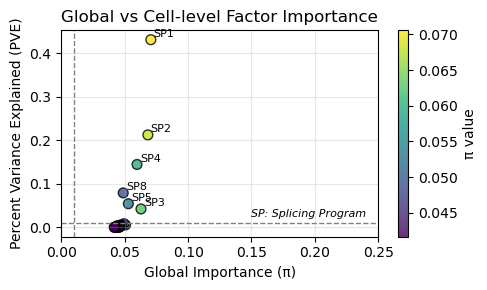

In [41]:
# Simple scatter plot
plt.figure(figsize=(5, 3))

# Use scatter with edgecolors for black outline and c parameter for color mapping
plt.scatter(new_pi, pve_factor_space, s=50, alpha=0.8, 
            c=new_pi, cmap='viridis', edgecolors='black', linewidth=1)

# Add colorbar to show π value mapping
plt.colorbar(label='π value')

# Add factor labels for interesting points
for i in range(len(new_pi)):
    if i < 5 or pve_factor_space[i] > 0.05:  # Label first 3 and high variance factors
        plt.annotate(f'SP{i+1}', (new_pi[i], pve_factor_space[i]), 
                    xytext=(2, 2), textcoords='offset points', fontsize=8)  # Increased from (5,5) to (10,10)

plt.xlabel('Global Importance (π)')
plt.ylabel('Percent Variance Explained (PVE)')
plt.title('Global vs Cell-level Factor Importance')
plt.xlim(0, 0.25)

# add dashed hori line at 0.01
plt.axhline(0.01, color='gray', linestyle='--', linewidth=1)
plt.axvline(0.01, color='gray', linestyle='--', linewidth=1)

# Add SP definition at bottom of plot
plt.text(0.15, 0.02, 'SP: Splicing Program', fontsize=8, style='italic', 
         transform=plt.gca().transData, verticalalignment='bottom')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/factor_pi_vs_pve.pdf


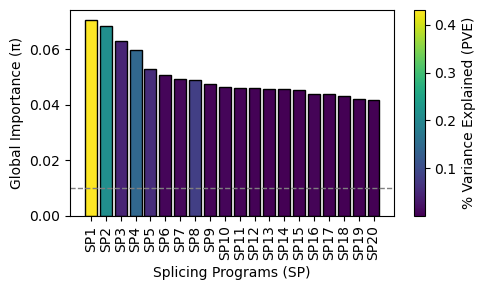

In [42]:
# Assume new_pi and pve_factor_space already exist
num_factors = len(new_pi)
factor_labels = [f'SP{i+1}' for i in range(num_factors)]

# Normalize PVE for colormap
norm = plt.Normalize(pve_factor_space.min(), pve_factor_space.max())
colors = plt.cm.viridis(norm(pve_factor_space))

# Set up figure and axis
fig, ax = plt.subplots(figsize=(5, 3))

# Bar plot
bars = ax.bar(
    factor_labels,
    new_pi,
    color=colors,
    edgecolor='black'
)

# Create scalar mappable and colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # Required dummy
cbar = plt.colorbar(sm, ax=ax)  # Pass ax explicitly
cbar.set_label("% Variance Explained (PVE)")

# Add horizontal threshold line
ax.axhline(0.01, color='gray', linestyle='--', linewidth=1)

# Formatting
ax.set_ylabel('Global Importance (π)')
ax.set_xlabel('Splicing Programs (SP)')
# ax.set_title('Factor Importance (π), colored by PVE')
ax.set_xticks(np.arange(num_factors))
ax.set_xticklabels(factor_labels, rotation=90, fontsize=10)

plt.tight_layout()

# Save to output_dir with today's date OUTPUT_DIR 
output_path = os.path.join(OUTPUT_DIR, f"factor_pi_vs_pve.pdf")
plt.savefig(output_path, format='pdf', bbox_inches='tight')
print(f"Plot saved to: {output_path}")

plt.show()


## Visualize Perplexity

In [43]:
PHI = splice_adata.obsm["X_PHI"]
PHI.shape

(142315, 20)

In [44]:
# Calculate cell perplexity/entropy 
print("Calculating cell perplexity...")
PHI_safe = np.clip(PHI, 1e-10, 1)  # Prevent log(0) errors
entropy = -np.sum(PHI_safe * np.log(PHI_safe), axis=1)
perplexity = np.exp(entropy)
splice_adata.obs["perplexity"] = perplexity

Calculating cell perplexity...


<Axes: >

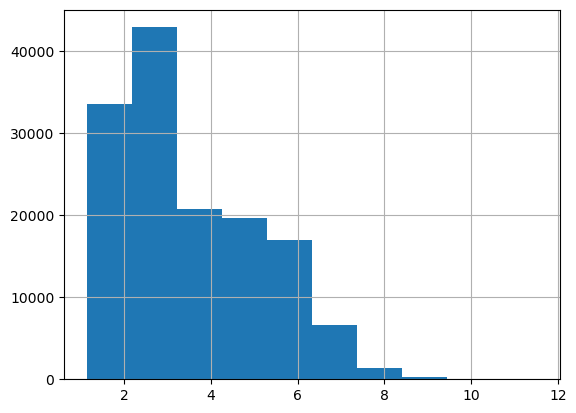

In [45]:
splice_adata.obs["perplexity"].hist()

In [46]:
splice_adata.obs["tissue_celltype"].value_counts()

tissue_celltype
Brain_Non-Myeloid_Excitatory Neurons (Cortical)       29127
Brain_Myeloid_Glial/Microglia                         11923
Brain_Non-Myeloid_Inhibitory Neurons (Vip+)            5026
Brain_Non-Myeloid_Inhibitory Neurons (Sst+)            4355
Skin_Epithelial (Skin)                                 4234
Brain_Non-Myeloid_Excitatory Neurons (Hippocampal)     4161
Marrow_B Cell Lineage                                  3836
Brain_Non-Myeloid_Inhibitory Neurons (Lamp5+)          3579
Marrow_Granulocyte/Myeloid                             3467
Large_Intestine_Epithelial (Gut)                       3157
Tongue_Epithelial (Skin)                               3093
Brain_Non-Myeloid_Inhibitory Neurons (Pvalb+)          3019
Heart_Fibroblast/Structural                            3011
Thymus_T Cell Lineage                                  3002
Marrow_Stem Cell (Blood)                               2748
Spleen_B Cell Lineage                                  2355
Heart_Endothelial (Vascu

In [47]:
# Step 4: Filter medium_cell_types with >= 50 cells
valid_medium_ct = (
    splice_adata.obs["tissue_celltype"]
    .value_counts()[lambda x: x >= 50]
    .index
)

valid_medium_ct

Index(['Brain_Non-Myeloid_Excitatory Neurons (Cortical)',
       'Brain_Myeloid_Glial/Microglia',
       'Brain_Non-Myeloid_Inhibitory Neurons (Vip+)',
       'Brain_Non-Myeloid_Inhibitory Neurons (Sst+)', 'Skin_Epithelial (Skin)',
       'Brain_Non-Myeloid_Excitatory Neurons (Hippocampal)',
       'Marrow_B Cell Lineage',
       'Brain_Non-Myeloid_Inhibitory Neurons (Lamp5+)',
       'Marrow_Granulocyte/Myeloid', 'Large_Intestine_Epithelial (Gut)',
       ...
       'Kidney_B Cell Lineage', 'Spleen_NK/Innate Lymphoid',
       'Brain_Non-Myeloid_Inhibitory Neurons (Meis2+)',
       'Diaphragm_Phagocytic/APCs', 'Kidney_T Cell Lineage',
       'Brain_Non-Myeloid_Neural Progenitor', 'SCAT_NK/Innate Lymphoid',
       'Heart_Phagocytic/APCs', 'Trachea_Smooth Muscle/Structural',
       'Trachea_Epithelial (Airway/Gut)'],
      dtype='object', name='tissue_celltype', length=133)

In [48]:
import anndata as ad

# Temporarily disable removing unused categories
ad.settings.remove_unused_categories = False

# Now try subsetting
mask = splice_adata.obs["tissue_celltype"].isin(valid_medium_ct)
splice_adata_subset = splice_adata[mask, :].copy()
ge_adata_subset = ge_adata[mask, :].copy()

# Re-enable if desired
ad.settings.remove_unused_categories = True

In [49]:
ad.settings.remove_unused_categories = False

In [50]:
# Subset AnnData object to only those cells
splice_adata = splice_adata_subset.copy()

# Ensure ge_adata is subsetted to match
ge_adata = ge_adata_subset.copy()

# Assert order of cells is the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [51]:
splice_adata, ge_adata

(AnnData object with n_obs × n_vars = 141454 × 70102
     obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'medium_cell_type', 'broad_cell_type', 'total_counts', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'tissue_celltype', 'perplexity'
     var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influence', 'RB

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/perplexity_by_age_rasterized.pdf


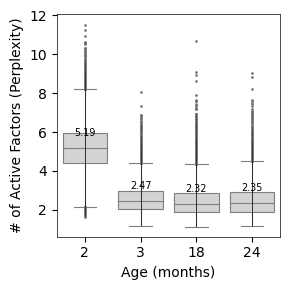

In [52]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("age_numeric", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Age (months)", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_age_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/perplexity_by_sex_rasterized.pdf


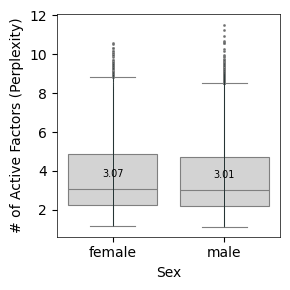

In [53]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("sex", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Sex", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_sex_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

In [54]:
from scipy.stats import mannwhitneyu, ttest_ind

# Split by sex
grouped = splice_adata.obs.groupby("sex", observed=True)["perplexity"]
groups = [vals.values for _, vals in grouped]

# Mann–Whitney U test
u_stat, p_val = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
print(f"Mann–Whitney U: U={u_stat:.2f}, p={p_val:.3e}")

# (Optional) parametric t-test
t_stat, p_val_t = ttest_ind(groups[0], groups[1], equal_var=False)
print(f"T-test: t={t_stat:.2f}, p={p_val_t:.3e}")


Mann–Whitney U: U=2432149091.00, p=1.070e-20
T-test: t=9.18, p=4.331e-20


In [55]:
splice_adata.obs["tissue_celltype"].value_counts()

tissue_celltype
Brain_Non-Myeloid_Excitatory Neurons (Cortical)       29127
Brain_Myeloid_Glial/Microglia                         11923
Brain_Non-Myeloid_Inhibitory Neurons (Vip+)            5026
Brain_Non-Myeloid_Inhibitory Neurons (Sst+)            4355
Skin_Epithelial (Skin)                                 4234
Brain_Non-Myeloid_Excitatory Neurons (Hippocampal)     4161
Marrow_B Cell Lineage                                  3836
Brain_Non-Myeloid_Inhibitory Neurons (Lamp5+)          3579
Marrow_Granulocyte/Myeloid                             3467
Large_Intestine_Epithelial (Gut)                       3157
Tongue_Epithelial (Skin)                               3093
Brain_Non-Myeloid_Inhibitory Neurons (Pvalb+)          3019
Heart_Fibroblast/Structural                            3011
Thymus_T Cell Lineage                                  3002
Marrow_Stem Cell (Blood)                               2748
Spleen_B Cell Lineage                                  2355
Heart_Endothelial (Vascu

Saved corrected plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/perplexity_by_cell_type_ordered_rasterized.pdf


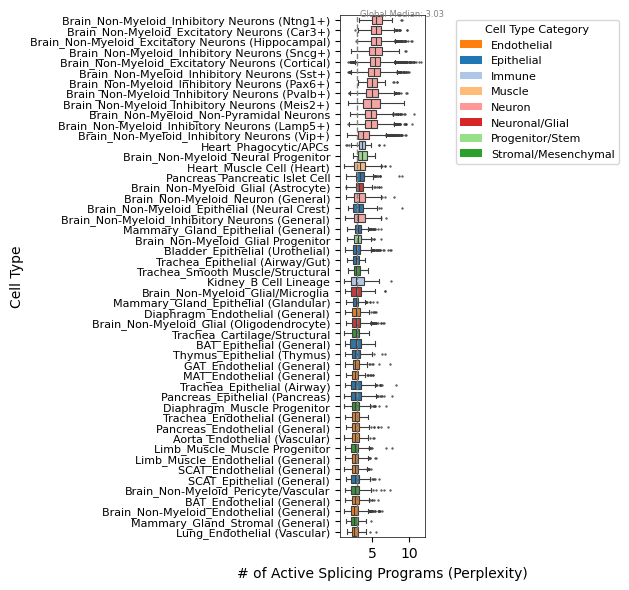

In [56]:
# --- The Complete, Corrected Plotting Script ---

## 🛠️ Step 1: Data Preparation

# Compute median perplexity by tissue_celltype and get top 20
median_order = (
    splice_adata.obs
    .groupby("tissue_celltype", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .head(50)
    .index
)

# Color palette for broad_cell_type
unique_broad = splice_adata.obs["broad_cell_type"].unique()
palette = sns.color_palette("tab20", len(unique_broad))
palette_dict = dict(zip(unique_broad, palette))

# Map the tissue_celltype to its broad_cell_type color
color_map = splice_adata.obs.set_index("tissue_celltype")["broad_cell_type"].to_dict()

# Create a list of colors in the exact order of the boxplots (median_order)
plot_colors = [palette_dict[color_map[cell_type]] for cell_type in median_order]


## 📊 Step 2: Main Plotting

# Start figure
fig, ax = plt.subplots(figsize=(8, 6))

# Main plot - REMOVE 'hue' and use 'plot_colors' to center the boxplots
bp = sns.boxplot(
    data=splice_adata.obs,
    y="tissue_celltype", 
    x="perplexity", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order,
    palette=plot_colors, # Use the pre-calculated list of colors
    ax=ax
)

# Rasterize fliers (optional, for PDF size optimization)
for c in ax.collections:
    if isinstance(c, plt.collections.PathCollection):
        c.set_rasterized(True)

# Global median line
global_median = splice_adata.obs["perplexity"].median()
ax.axvline(global_median, color='gray', linestyle='--', linewidth=1)
ax.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
        color='gray', fontsize=6, va='top')


## 🎨 Step 3: Legend and Formatting

# Manually create the legend since 'hue' was removed
# 1. Get unique broad cell types present in the top 20
broad_types_in_plot = sorted(list(set(color_map[cell] for cell in median_order)))

# 2. Create legend handles and labels
handles = [plt.Rectangle((0, 0), 1, 1, fc=palette_dict[bt]) for bt in broad_types_in_plot]
labels = broad_types_in_plot

ax.legend(
    handles=handles,
    labels=labels,
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
ax.set_ylabel("Cell Type", fontsize=10)
ax.set_xlabel("# of Active Splicing Programs (Perplexity)", fontsize=10)
ax.tick_params(axis='y', labelsize=8)

# Border
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Save
plt.tight_layout()
pdf_path = f"{OUTPUT_DIR}/perplexity_by_cell_type_ordered_rasterized.pdf"
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Saved corrected plot to: {pdf_path}")
plt.show()

Saved corrected plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/perplexity_by_cell_type_ordered_rasterized_100.pdf


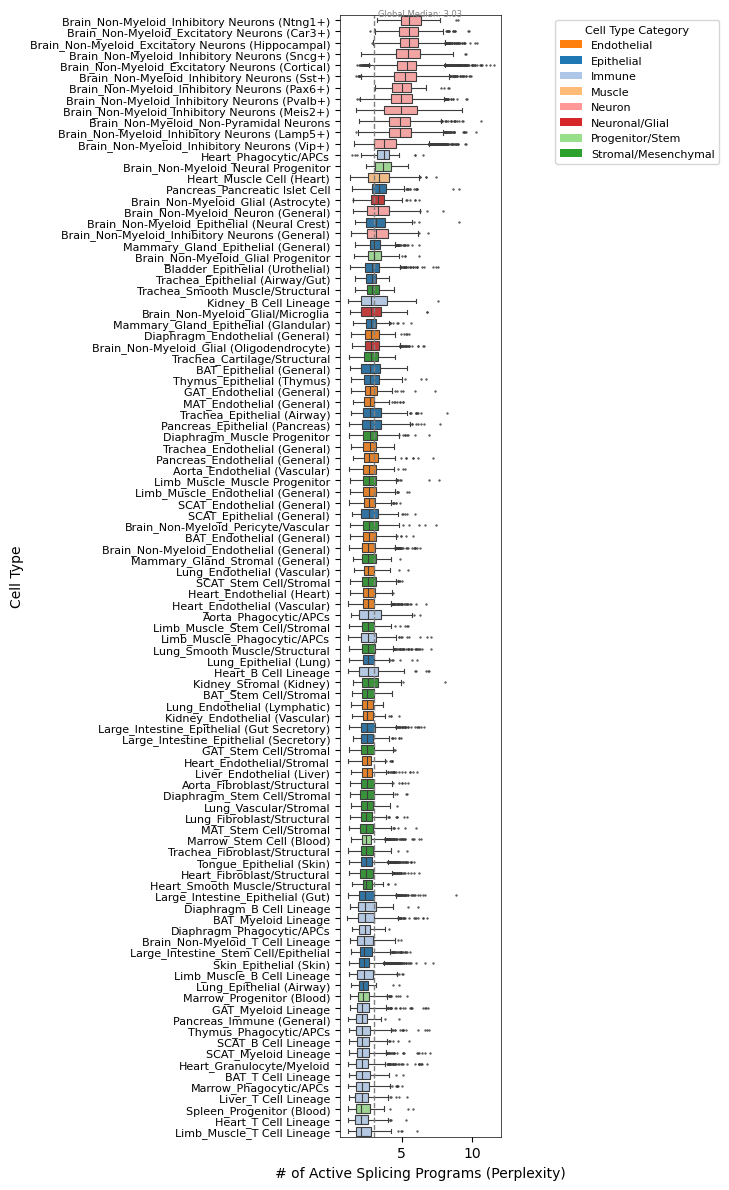

In [61]:
# --- The Complete, Corrected Plotting Script ---

## 🛠️ Step 1: Data Preparation

# Compute median perplexity by tissue_celltype and get top 20
median_order = (
    splice_adata.obs
    .groupby("tissue_celltype", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .head(100)
    .index
)

# Color palette for broad_cell_type
unique_broad = splice_adata.obs["broad_cell_type"].unique()
palette = sns.color_palette("tab20", len(unique_broad))
palette_dict = dict(zip(unique_broad, palette))

# Map the tissue_celltype to its broad_cell_type color
color_map = splice_adata.obs.set_index("tissue_celltype")["broad_cell_type"].to_dict()

# Create a list of colors in the exact order of the boxplots (median_order)
plot_colors = [palette_dict[color_map[cell_type]] for cell_type in median_order]


## 📊 Step 2: Main Plotting

# Start figure
fig, ax = plt.subplots(figsize=(9, 12))

# Main plot - REMOVE 'hue' and use 'plot_colors' to center the boxplots
bp = sns.boxplot(
    data=splice_adata.obs,
    y="tissue_celltype", 
    x="perplexity", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order,
    palette=plot_colors, # Use the pre-calculated list of colors
    ax=ax
)

# Rasterize fliers (optional, for PDF size optimization)
for c in ax.collections:
    if isinstance(c, plt.collections.PathCollection):
        c.set_rasterized(True)

# Global median line
global_median = splice_adata.obs["perplexity"].median()
ax.axvline(global_median, color='gray', linestyle='--', linewidth=1)
ax.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
        color='gray', fontsize=6, va='top')


## 🎨 Step 3: Legend and Formatting

# Manually create the legend since 'hue' was removed
# 1. Get unique broad cell types present in the top 20
broad_types_in_plot = sorted(list(set(color_map[cell] for cell in median_order)))

# 2. Create legend handles and labels
handles = [plt.Rectangle((0, 0), 1, 1, fc=palette_dict[bt]) for bt in broad_types_in_plot]
labels = broad_types_in_plot

ax.legend(
    handles=handles,
    labels=labels,
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
ax.set_ylabel("Cell Type", fontsize=10)
ax.set_xlabel("# of Active Splicing Programs (Perplexity)", fontsize=10)
ax.tick_params(axis='y', labelsize=8)

# Border
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Save
plt.tight_layout()
pdf_path = f"{OUTPUT_DIR}/perplexity_by_cell_type_ordered_rasterized_100.pdf"
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Saved corrected plot to: {pdf_path}")
plt.show()

In [63]:
splice_adata.obs[splice_adata.obs["broad_cell_type"] == "Muscle"]["perplexity"].median()

3.407789391550633

In [62]:
splice_adata.obs[splice_adata.obs["broad_cell_type"] == "Immune"]["perplexity"].median()

2.111679193528727

In [58]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import utils  # or: from utils import your_function
import importlib
importlib.reload(utils)

<module 'utils' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/utils.py'>

## Get correlation matrix plot

In [59]:
# Remake PHI matrix correlation plot
X_PHI_corr_matrix = plot_correlation_matrix(splice_adata.obsm["X_PHI"], OUTPUT_DIR)

Saved correlation matrix to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/correlation_matrix_PHI.pdf


## Quick scVI check

In [64]:
np.all(splice_adata.obs_names == ge_adata.obs_names)

True

## More detailed aging analysis

### Figure 2 Factor Covaraites Labels

In [65]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

def run_variance_explained_analysis(
    splice_adata, 
    sample_id,
    cell_type_col,
    PLOTS_DIR=None, 
    DATA_DIR=None,
    f_display_mode="log10",       # "raw", "log10", "zscore_by_term"
    f_clip_percentile=99,         # upper clip for F visualization
    plot_prop=True,               # plot PropSS heatmap
    plot_F=True                   # plot F-stat heatmap
):
    """
    Variance attribution for splicing programs (LeafletFA factors).

    Steps:
      1) Z-score factors (columns) to remove scale bias.
      2) OLS per factor with Type-II ANOVA:
           SP_k ~ C(cell_type) + C(tissue) + C(sex) + age + C(dataset)
                   + C(cell_type):age + C(sex):age
      3) Plot:
         (A) Proportion of explained variance (sum_sq share) per factor×term
         (B) F-statistic heatmap, with display modes:
              - "raw": clipped raw F
              - "log10": log10(F+1) then clip
              - "zscore_by_term": column-wise z-score of F
         Both use identical row order (from PropSS clustering if available).
    Returns:
      dict with raw/processed tables and row order used for plotting.
    """
    print("Running variance explained analysis...")

    # ---------- Build analysis frame with z-scored factors ----------
    X_phi = splice_adata.obsm["X_PHI"]
    X_phi_z = StandardScaler(with_mean=True, with_std=True).fit_transform(X_phi)
    factor_names = [f"SP_{i+1}" for i in range(X_phi_z.shape[1])]
    analysis_df = pd.DataFrame(X_phi_z, index=splice_adata.obs_names, columns=factor_names)

    # Covariates
    obs_cols_to_copy = {
        cell_type_col: "cell_type",
        "tissue": "tissue",
        "sex": "sex",
        sample_id: "dataset",
        "age_numeric": "age",
    }
    for obs_col, df_col in obs_cols_to_copy.items():
        analysis_df[df_col] = splice_adata.obs[obs_col].values

    # ---------- Model terms ----------
    base_terms = ['C(cell_type)', 'C(tissue)', 'C(sex)', 'age', 'C(dataset)']
    interaction_terms = ['C(cell_type):age', 'C(sex):age']
    all_terms = base_terms + interaction_terms

    # ---------- Fit OLS + ANOVA per factor ----------
    r2_records, anova_tables = [], []
    for factor_col in tqdm(factor_names, desc="Analyzing factors for variance explained"):
        formula = f"{factor_col} ~ " + " + ".join(all_terms)
        model = smf.ols(formula, data=analysis_df, missing='drop').fit()
        if model.nobs < (model.df_model + 2) or model.df_resid <= 0:
            print(f"Skipping {factor_col}: insufficient observations")
            continue
        r2_records.append({'SP': factor_col, 'r2_overall': model.rsquared, 'n_obs': int(model.nobs)})
        a2 = anova_lm(model, typ=2)
        a2['SP'] = factor_col
        anova_tables.append(a2.reset_index())

    r2_df = pd.DataFrame(r2_records)
    anova_df = pd.concat(anova_tables, ignore_index=True)

    # ---------- Clean & ensure numeric ----------
    anova_df = anova_df.rename(columns={'index': 'covariate_term'})
    anova_df = anova_df[anova_df['covariate_term'] != 'Residual'].copy()
    for col in ['sum_sq', 'F']:
        anova_df[col] = pd.to_numeric(anova_df[col], errors='coerce')

    # ---------- (A) Proportion of explained variance (PropSS) ----------
    ss_pivot = anova_df.pivot_table(index='SP', columns='covariate_term', values='sum_sq', aggfunc='sum')
    ss_pivot = ss_pivot.loc[:, (ss_pivot.sum(axis=0).abs() > 1e-12)]
    total_ss = ss_pivot.sum(axis=1)
    prop_var = ss_pivot.div(total_ss.replace(0, np.nan), axis=0)

    # Row labels with R^2
    r2_map = (
        r2_df.set_index('SP')
            .loc[prop_var.index]
            .assign(row=lambda d: [f"{sp} (R²={r2:.2f})" for sp, r2 in zip(d.index, d['r2_overall'])])
            ['row'].to_dict()
    )
    prop_var_disp = prop_var.rename(index=r2_map).astype(float)

    # ---------- (B) F-statistic processing ----------
    f_pivot = anova_df.pivot_table(index='SP', columns='covariate_term', values='F', aggfunc='mean')
    f_pivot = f_pivot.reindex(prop_var.index)  # align to PropSS row order

    F_vis = f_pivot.replace([np.inf, -np.inf], np.nan).copy()
    cbar_label = ""
    cmap = "viridis"; vmin = None; vmax = None

    if f_display_mode == "log10":
        F_vis = np.log10(F_vis + 1.0)
        cbar_label = "log₁₀(F + 1)"
        clip_hi = np.nanpercentile(F_vis.values.ravel(), f_clip_percentile) if np.isfinite(F_vis.values).any() else None
        if clip_hi and clip_hi > 0:
            F_vis = F_vis.clip(upper=clip_hi)
        vmin, vmax = 0, clip_hi
    elif f_display_mode == "zscore_by_term":
        # column-wise z-score
        F_vis = (F_vis - F_vis.mean(axis=0)) / F_vis.std(axis=0)
        cbar_label = "F (z-score within term)"
        clip_hi = np.nanpercentile(F_vis.values.ravel(), f_clip_percentile)
        clip_lo = np.nanpercentile(F_vis.values.ravel(), 100 - f_clip_percentile)
        F_vis = F_vis.clip(lower=clip_lo, upper=clip_hi)
        cmap = "PRGn"
        vmin, vmax = None, None
    else:  # "raw"
        cbar_label = "F-statistic (clipped)"
        clip_hi = np.nanpercentile(F_vis.values.ravel(), f_clip_percentile) if np.isfinite(F_vis.values).any() else None
        if clip_hi and clip_hi > 0:
            F_vis = F_vis.clip(upper=clip_hi)
        cmap = "viridis"
        vmin, vmax = 0, clip_hi

    F_disp = F_vis.rename(index=r2_map).astype(float)

    # ---------- Plot A: PropSS ----------
    cg_prop = None
    if plot_prop:
        width, height = 5.0, 4.0
        annot_prop = prop_var_disp.round(2).astype(str)
        cg_prop = sns.clustermap(
            prop_var_disp, cmap="PRGn", center=0,
            linewidths=0.2, linecolor='black',
            annot=annot_prop, fmt='',
            annot_kws={"size": 4, "color": "grey"},
            figsize=(width, height),
            xticklabels=True, yticklabels=True,
            vmin=0, vmax=1.0
        )
        plt.setp(cg_prop.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        plt.setp(cg_prop.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
        cg_prop.ax_heatmap.set_xlabel('Covariate Terms', fontsize=11, fontweight='bold')
        cg_prop.ax_heatmap.set_ylabel('LeafletFA Splicing Programs', fontsize=11, fontweight='bold')
        if PLOTS_DIR:
            out_prop = os.path.join(PLOTS_DIR, f"variance_explained_propSS_{cell_type_col}.pdf")
            cg_prop.savefig(out_prop, format="pdf", bbox_inches="tight")
            print(f"  Saved: {out_prop}")

    # ---------- Plot B: F-stat ----------
    if plot_F:
        # keep same row order as PropSS if we clustered it
        if cg_prop is not None and cg_prop.dendrogram_row is not None:
            row_idx = cg_prop.dendrogram_row.reordered_ind
            F_disp_ordered = F_disp.iloc[row_idx]
        else:
            F_disp_ordered = F_disp

        # sparse annotations: only show top 5% values for readability (for log/raw modes)
        if f_display_mode in ("raw", "log10"):
            thresh = np.nanpercentile(F_disp_ordered.values.ravel(), 95)
            annot_F = F_disp_ordered.where(F_disp_ordered >= thresh).round(2).astype(str)
        else:
            annot_F = F_disp_ordered.round(2).astype(str)

        cg_F = sns.clustermap(
            F_disp_ordered,
            cmap=cmap,
            linewidths=0.2, linecolor='black',
            annot=annot_F, fmt='',
            annot_kws={"size": 4},
            figsize=(5, 4),
            xticklabels=True, yticklabels=True,
            col_cluster=True, row_cluster=(cg_prop is None),
            vmin=vmin, vmax=vmax
        )
        plt.setp(cg_F.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        plt.setp(cg_F.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
        cg_F.ax_heatmap.set_xlabel('Covariate Terms', fontsize=11, fontweight='bold')
        cg_F.ax_heatmap.set_ylabel('LeafletFA Splicing Programs', fontsize=11, fontweight='bold')
        cbar = cg_F.ax_heatmap.collections[0].colorbar
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label(cbar_label, fontsize=9)
        if PLOTS_DIR:
            out_F = os.path.join(PLOTS_DIR, f"variance_explained_Fstat_{f_display_mode}_{cell_type_col}.pdf")
            cg_F.savefig(out_F, format="pdf", bbox_inches="tight")
            print(f"  Saved: {out_F}")

    plt.show()

    return {
        "anova_raw": anova_df,           # long-form ANOVA table (no residual)
        "prop_var": prop_var,            # proportions per factor × term
        "F_raw": f_pivot,                # raw (unclipped) F values
        "prop_var_display": prop_var_disp,
        "F_display": F_disp,             # processed for visualization
        "r2": r2_df
    }

Running variance explained analysis...


Analyzing factors for variance explained: 100%|██████████| 20/20 [01:55<00:00,  5.76s/it]


  Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/variance_explained_propSS_tissue_celltype.pdf
  Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/variance_explained_Fstat_log10_tissue_celltype.pdf


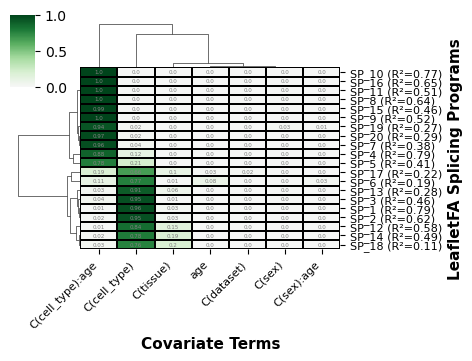

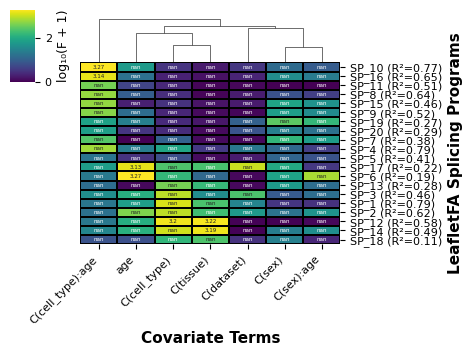

In [66]:
# read in factor labels 
factor_labels_medium_cell_type = run_variance_explained_analysis(splice_adata, cell_type_col="tissue_celltype", sample_id="dataset", PLOTS_DIR=OUTPUT_DIR)

In [67]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import figure_plotting
import importlib
importlib.reload(figure_plotting)

<module 'figure_plotting' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/figure_plotting.py'>

### Subset aging dataset

In [68]:
# subset to cells with age > 2 and at least 100 young and 100 old cells
splice_adata_full = splice_adata.copy()

# filter to cells with age > 2
# splice_adata = splice_adata[splice_adata.obs["age_numeric"] > 2].copy()
# counts = splice_adata.obs.groupby(["medium_cell_type", "age_group"]).size().unstack(fill_value=0)
# eligible_ct = counts.index[(counts["young"] >= 100) & (counts["old"] >= 100)]

# Apply filter
# splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(eligible_ct)].copy()
# print(f"Number of cell types after filtering: {len(splice_adata.obs['medium_cell_type'].unique())}")
# print(f"Number of cells after filtering: {splice_adata.n_obs}")

ge_adata_full = ge_adata.copy()
ge_adata = ge_adata[splice_adata.obs_names].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)


Top 2 positively correlated factor pairs:
factor_i factor_j      rho
     SP4      SP5 0.873486
     SP5      SP8 0.862983

Top 2 negatively correlated factor pairs:
factor_i factor_j       rho
     SP8     SP18 -0.542898
     SP5     SP18 -0.538301

Top 2 least correlated factor pairs:
factor_i factor_j       rho
     SP9     SP18  0.000282
    SP11     SP14 -0.000687


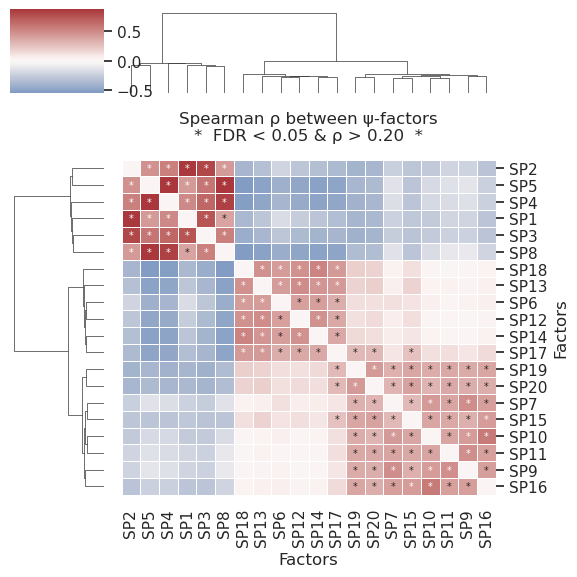

In [69]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests   # pip install statsmodels

# ── 1.  Data → DataFrame ───────────────────────────────────────────────────────
ψ  = splice_adata.varm["psi_learned"]          # (J, K)
K  = ψ.shape[1]

# Subtract row (junction) mean from each factor value
ψ_centered = ψ - np.nanmean(ψ, axis=1, keepdims=True)
K = ψ_centered.shape[1]
df = pd.DataFrame(ψ_centered, columns=[f"SP{j+1}" for j in range(K)])

# ── 2.  ρ and p-values for *each* pair ─────────────────────────────────────────
rho    = np.zeros((K, K))
pvals  = np.ones((K, K))

for i in range(K):
    for j in range(i+1, K):
        r, p = spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
        rho[i, j] = rho[j, i] = r
        pvals[i, j] = pvals[j, i] = p

# ── 3.  Benjamini–Hochberg FDR adjustment over the upper triangle ─────────────
tri_idx         = np.triu_indices(K, k=1)          # exclude the diagonal
p_flat          = pvals[tri_idx]
_, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
qvals           = np.ones_like(pvals)
qvals[tri_idx]  = qvals.T[tri_idx] = q_flat

# ── 4.  Significance mask  (FDR < 0.05 and ρ > 0.20) ──────────────────────────
star_mask = (qvals < 0.05) & (rho > 0.20)
annot     = np.where(star_mask, "*", "")

# ── 5.  Build DataFrames with indices/columns for seaborn ─────────────────────
rho_df   = pd.DataFrame(rho,   index=df.columns, columns=df.columns)
annot_df = pd.DataFrame(annot, index=df.columns, columns=df.columns)


# ── 1.  clustered heat-map with all tick labels ───────────────────────────────
sns.set_theme(style="white")
g = sns.clustermap(
    rho_df,
    cmap="vlag", center=0, linewidths=0.4, square=True,
    metric="euclidean", row_cluster=True, col_cluster=True,
    figsize=(6, 6),
    annot=annot_df, fmt="", annot_kws={"size":7},
    xticklabels=True, yticklabels=True
)

# Rotate x-labels so they don’t overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_heatmap.set_title("Spearman ρ between ψ-factors\n*  FDR < 0.05 & ρ > 0.20  *", pad=14)
g.ax_heatmap.set_xlabel("Factors")
g.ax_heatmap.set_ylabel("Factors")

plt.tight_layout()

# ── 2.  save to disk ──────────────────────────────────────────────────────────
g.savefig(f"{OUTPUT_DIR}/psi_factor_spearman_clustermap.pdf", bbox_inches="tight")

# ── 3.  report extreme pairs ──────────────────────────────────────────────────
# flatten upper triangle (exclude diagonal), keep finite values only
tri_i, tri_j = np.triu_indices_from(rho_df, k=1)
tri_vals = rho_df.values[tri_i, tri_j]

# build a DataFrame for easy sorting
pairs_df = pd.DataFrame({
    "factor_i": rho_df.index[tri_i],
    "factor_j": rho_df.columns[tri_j],
    "rho":      tri_vals
}).dropna()

# top 2 positive
top_pos = pairs_df.nlargest(2, "rho")
# top 2 negative
top_neg = pairs_df.nsmallest(2, "rho")
# top 2 least correlated (closest to zero)
top_flat = pairs_df.iloc[(pairs_df["rho"].abs()).nsmallest(2).index]

print("\nTop 2 positively correlated factor pairs:")
print(top_pos.to_string(index=False))

print("\nTop 2 negatively correlated factor pairs:")
print(top_neg.to_string(index=False))

print("\nTop 2 least correlated factor pairs:")
print(top_flat.to_string(index=False))


In [70]:
splice_adata.obs["SP_1"]

cell_id
A10_B000120          0.380671
A10_B000126          0.518532
A10_B000127          0.835092
A10_B000166          0.179168
A10_B000169          0.713754
                       ...   
US-1250275_E2_S86    0.005525
US-1250275_E2_S87    0.016435
US-1250275_E2_S88    0.007106
US-1250275_E2_S89    0.001506
US-1250275_E2_S90    0.001579
Name: SP_1, Length: 141454, dtype: float64

<Axes: xlabel='age_numeric', ylabel='SP_1'>

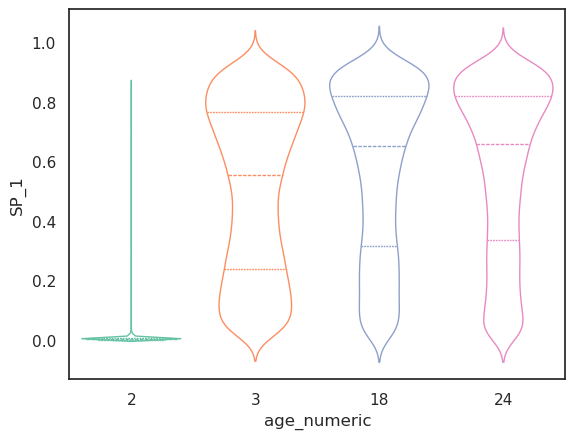

In [72]:
sns.violinplot(
        data=splice_adata.obs,
        linewidth=1, linecolor="k",
        x="age_numeric",    palette="Set2",
        inner="quart",
        y="SP_1", fill=False)
    

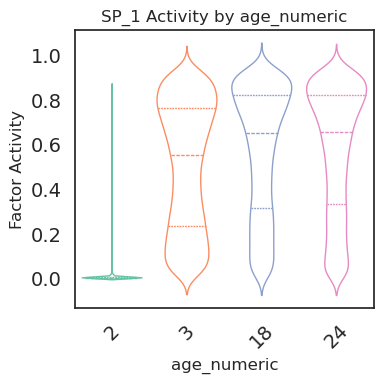

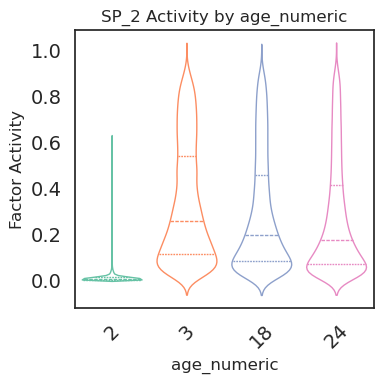

In [73]:
df = splice_adata_full.obs
groupby = "age_numeric"
include_groups = ["SP_1", "SP_2"]
factor_list = ["SP_1", "SP_2"]
figsize = (4, 4)
save_prefix = "factor_age_violin"

for factor in factor_list:
    plt.figure(figsize=figsize)
    sns.violinplot(
        data=df,
        linewidth=1, linecolor="k",
        x=groupby,    palette="Set2",
        inner="quart",
        y=factor, fill=False)
    
    plt.title(f"{factor} Activity by {groupby}")
    plt.xlabel(groupby)
    plt.ylabel("Factor Activity")
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_{factor}_by_{groupby}.pdf", format="pdf")
    plt.show()

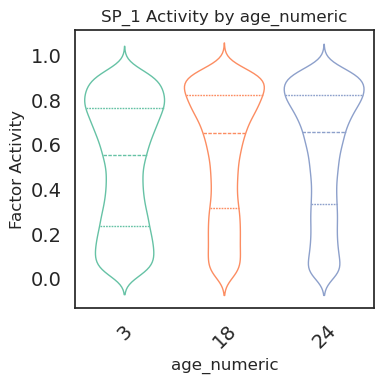

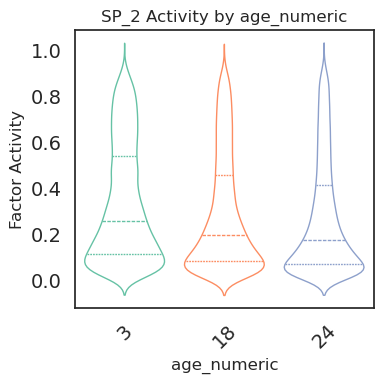

In [74]:
plot_factor_violin(
    adata=splice_adata_full[splice_adata_full.obs["age_numeric"] > 2],
    factor_list=["SP_1", "SP_2"],
    groupby="age_numeric",
    save_prefix="factor_age_violin"
)

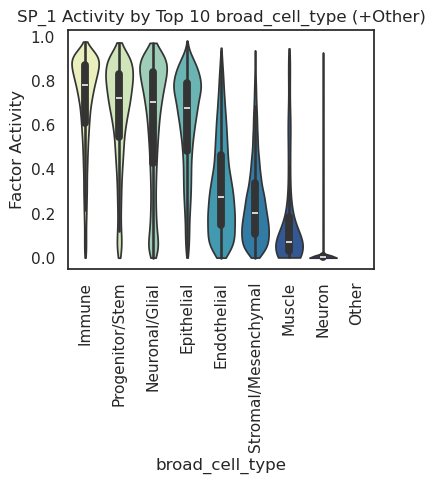

In [75]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

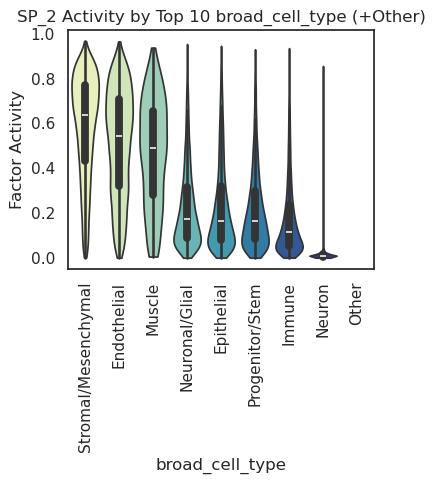

In [76]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_2"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

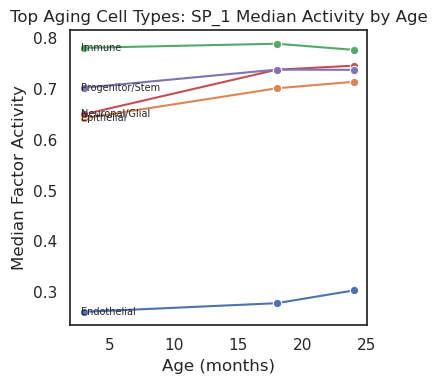

In [77]:
plot_factor_age_trends(
    df=splice_adata.obs[splice_adata.obs["age_numeric"] > 2],
    factor="SP_1",
    top_n=5,
    title_prefix="Top Aging Cell Types",
    save_path=f"{OUTPUT_DIR}/Factor_1_age_trend_top3.pdf"
)


### Get heatmap for common cell types 

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/clustering_common_celltype_dataset_factors.pdf


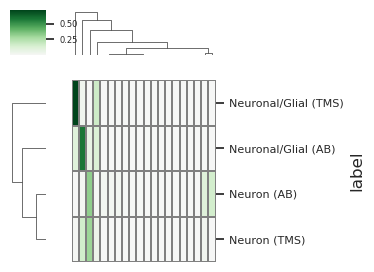

In [78]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = splice_adata_full.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["AB"] > 0) & (cell_type_counts["TMS"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()

# Subset to common cell types
adata_common = splice_adata_full[
    splice_adata_full.obs["broad_cell_type"].isin(common_cell_type_names)
].copy()

# Convert to categorical first
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].astype("category")
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor matrix and build DataFrame
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i+1}" for i in range(num_factors)]

df = adata_common.obs[["broad_cell_type", "dataset"]].copy()
for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

# Compute median factor values by cell type and dataset
median_profiles = (
    df.groupby(["broad_cell_type", "dataset"], observed=True)[factor_cols]
    .median()
    .reset_index()
)

# Create composite labels
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

# Set label as index
median_profiles = median_profiles.set_index("label")[factor_cols]

# Plot clustermap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(4, 3)
)

# Remove x-axis tick labels (factors)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xticklabels([])

# Format y-axis (cell types)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)

# Colorbar label and tick font
g.ax_cbar.set_label("Median Factor Activity")
g.ax_cbar.yaxis.label.set_size(7)
g.ax_cbar.tick_params(labelsize=6)

# Save
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf", bbox_inches='tight')
print(f"Saved plot to {OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf")
plt.show()

In [79]:
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].astype("category")
splice_adata.obs["medium_cell_type"] = splice_adata.obs["medium_cell_type"].astype("category")

  broad_cell_type age_numeric      SP_4
0          Neuron           2  0.325430
1          Neuron           3  0.503207
2          Neuron          18  0.148980
3          Neuron          24  0.300964


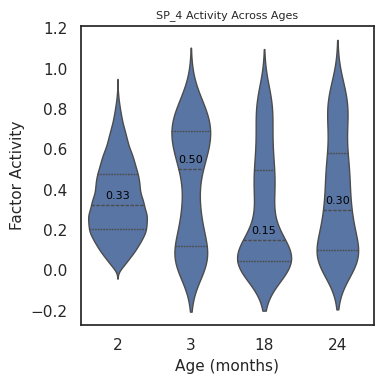

In [80]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="SP_4",
    cell_types=["Neuron"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


  broad_cell_type age_numeric      SP_4
0          Neuron           2  0.325430
1          Neuron           3  0.503207
2          Neuron          18  0.148980
3          Neuron          24  0.300964


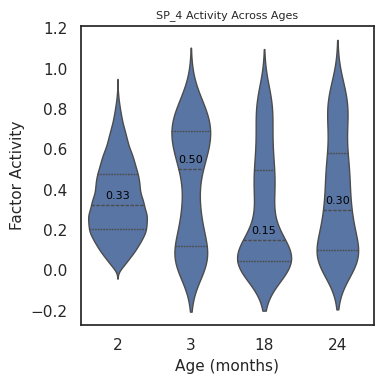

In [81]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="SP_4",
    cell_types=["Neuron"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


## Look at sig junctions from differential splicing analysis

In [82]:
# Run the analysis
print("="*60)
print("TOP JUNCTIONS PER FACTOR PSI ANALYSIS")
print("="*60)

# Step 1: Get top junctions per factor
top_junctions_dict, subset_splice_adata, junction_factor_map = get_top_junctions_per_factor(
    diff_spl, 
    splice_adata, 
    top_n=10, 
    effect_size_col='abs_effect_size'
)

# Get unique junction indices
unique_junctions = junction_factor_map['junction_idx'].unique()

# Extract PSI learned values for these junctions
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]

TOP JUNCTIONS PER FACTOR PSI ANALYSIS
Getting top 10 junctions per factor...
Ranking by: abs_effect_size
Found 20 factors: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Factor 0: 10 junctions, effect size range: 0.946 - 0.985
Factor 1: 10 junctions, effect size range: 0.918 - 0.937
Factor 2: 10 junctions, effect size range: 0.851 - 0.956
Factor 3: 10 junctions, effect size range: 0.832 - 0.884
Factor 4: 10 junctions, effect size range: 0.795 - 0.870
Factor 5: 10 junctions, effect size range: 0.970 - 0.987
Factor 6: 10 junctions, effect size range: 0.918 - 0.959
Factor 7: 10 junctions, effect size range: 0.850 - 0.887
Factor 8: 10 junctions, effect size range: 0.882 - 0.971
Factor 9: 10 junctions, effect size range: 0.917 - 0.971
Factor 10: 10 junctions, effect size range: 0.830 - 0.943
Factor 11: 10 junctions, effect size range: 0.971 - 0.993
Factor 12: 10 junctions, effect size range: 0.963 - 0.977
Factor 13: 10 junctions, effect size range: 0.974 - 0.986
Fact

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/psi_clustermap_top_10.pdf


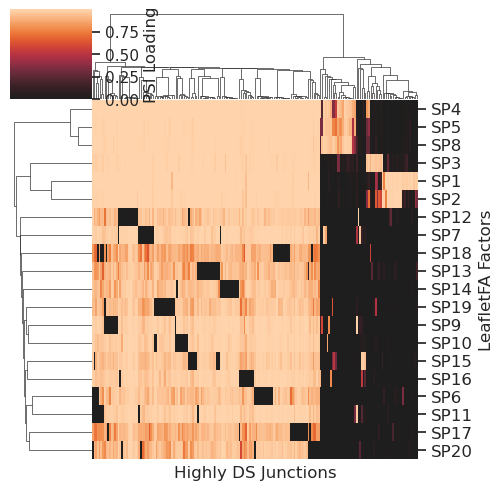

In [83]:
# 1. Map row labels: get junction_id or gene_name from .var
# Get the integer indices into .varm (which uses original order)
unique_junctions = junction_factor_map['junction_idx'].unique()
# psi_learned: shape (n_junctions, n_factors), so index using integer indices
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]
junction_id = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["junction_id"].values
gene_name = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["gene_name"].values

# Get number of factors (rows after transpose)
num_factors = psi_subset.shape[1]

# Create factor labels: F1, F2, ..., FK
factor_labels = [f"SP{i+1}" for i in range(num_factors)]

# 2. Create clustermap with color tweaks
g = sns.clustermap(
    psi_subset.T,
    center=0,
    figsize=(6, 5),
    xticklabels=False,
    yticklabels=factor_labels,
    cbar_kws={'label': 'PSI Loading'},
    robust=True  # clip extreme values for better contrast
)

# 3. Style adjustments
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)
g.ax_heatmap.set_ylabel("LeafletFA Factors")
g.ax_heatmap.set_xlabel("Highly DS Junctions")
plt.subplots_adjust(left=0.3, bottom=0.05, top=0.95, right=0.98)
save_path = os.path.join(OUTPUT_DIR, "psi_clustermap_top_10.pdf")
g.savefig(save_path, bbox_inches="tight")
print(f"Saved plot to {save_path}")
plt.show()

## Get UMAP on X_PHI

In [84]:
ge_adata.layers["scVI_linear"] = ge_adata.obsm["X_normalized_scVI_linear"]

In [ ]:
# Run neighbors and UMAP on X_PHI embedding
# sc.pp.neighbors(filtered_splice_adata, use_rep="X_PHI", n_neighbors=8)
# sc.tl.umap(filtered_splice_adata, random_state=0, min_dist=0.3)

In [ ]:
#plot_gene_and_factor_umap_from_phi(
#    splice_adata=filtered_splice_adata,
#    ge_adata=filtered_ge_adata,
#    gene_name="ZWINT",
#    factor_name="Factor_2",
#    groupby="broad_cell_type",
#    group_level="Microglia"
#)

In [85]:
ge_adata.obs["SP_1"] = splice_adata.obs["SP_1"]
ge_adata.obs["SP_2"] = splice_adata.obs["SP_2"]

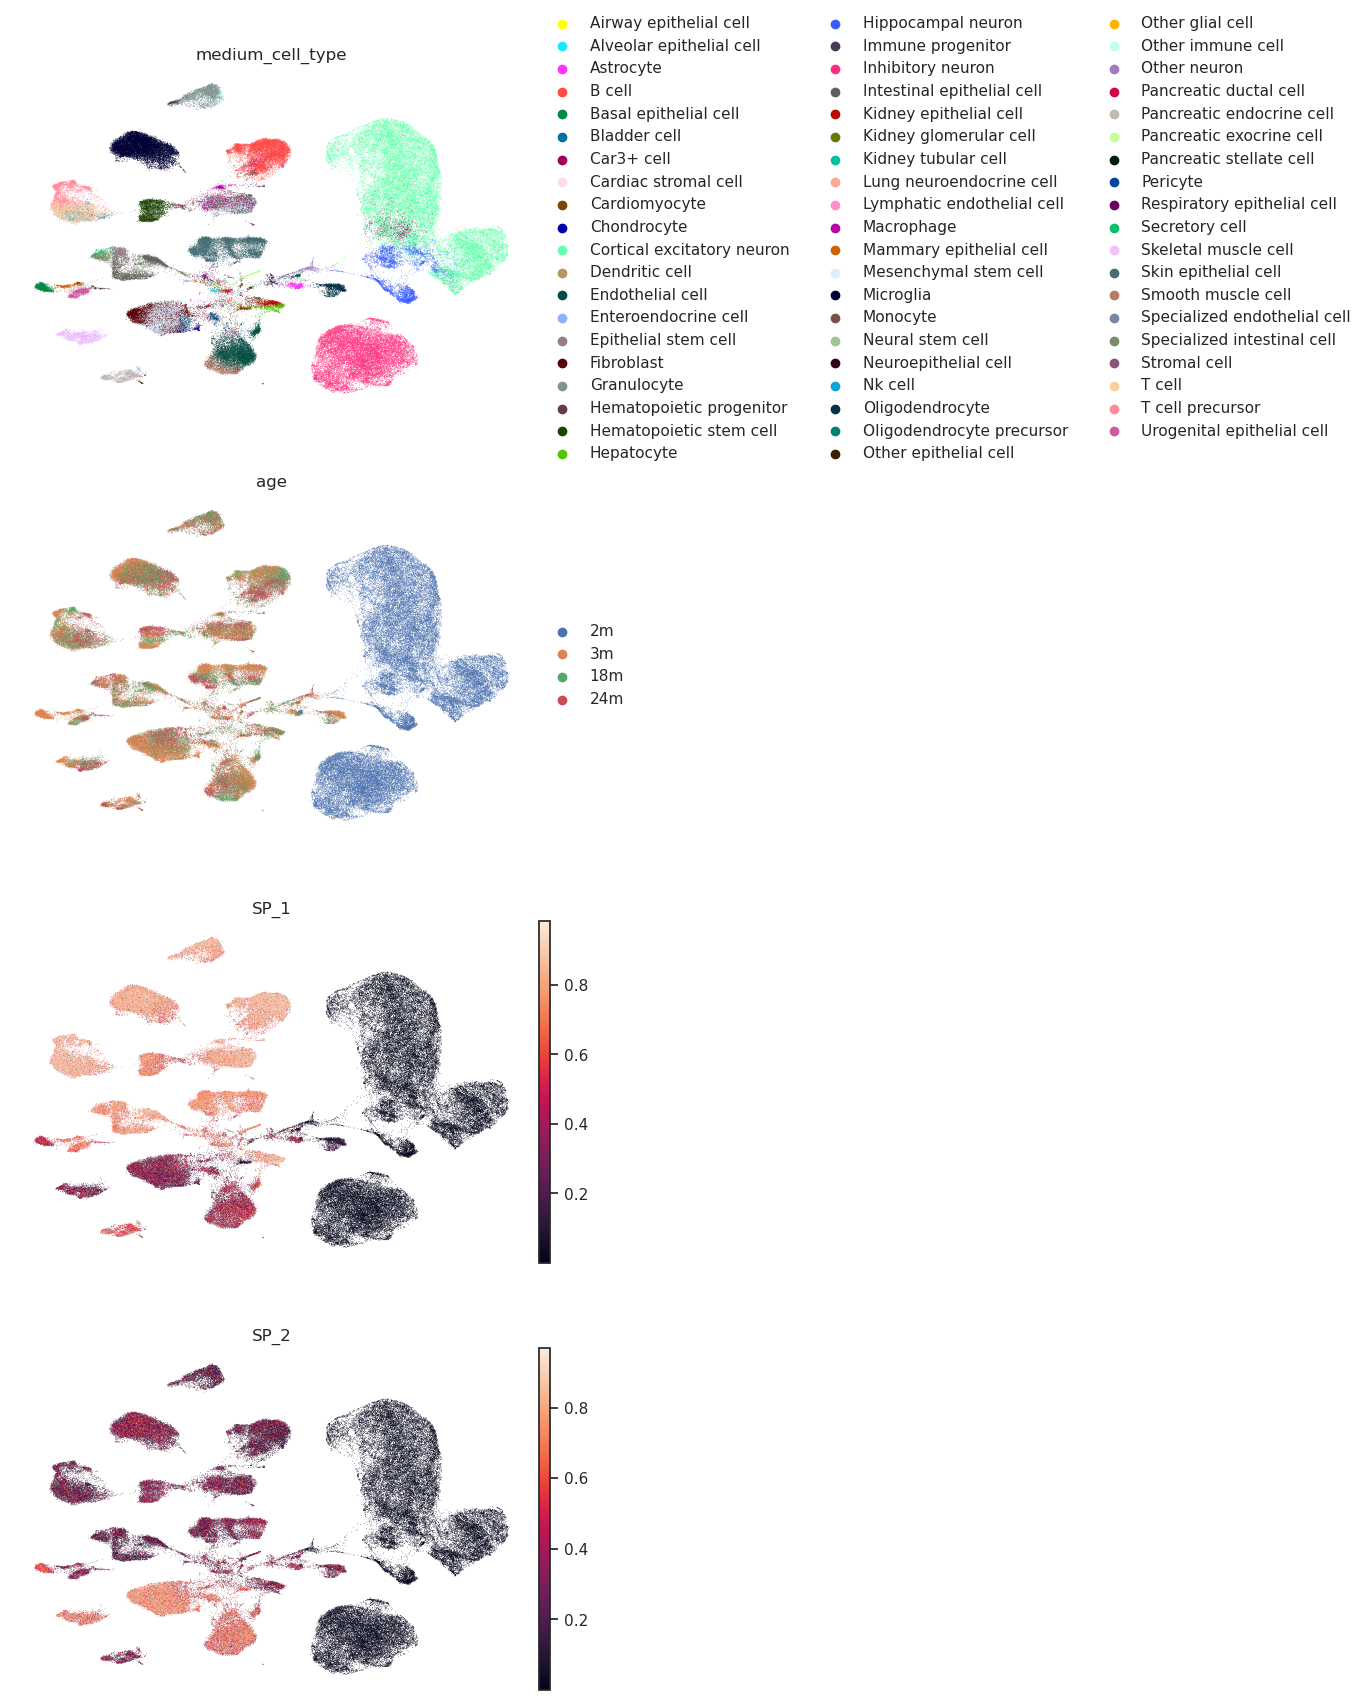

In [86]:
# Multiple plots in one figure
sc.pl.umap(ge_adata, 
           color=['medium_cell_type', 'age', 'SP_1', 'SP_2'],
           ncols=1,
           frameon=False,
           save='_multiplot.pdf')

### New circle heatmap combining delta age and activity across cell types

In [87]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Circle, Rectangle
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_factor_circles(adata, cell_type_col='broad_cell_type', age_col='age_group'):
    """
    Clustered tile plot: background color shows delta PSI (old - young),
    circle outlines show activity (median nonzero expression).
    """
    # Extract factor matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"SP_{i+1}" for i in range(n_factors)]
    factor_df = pd.DataFrame(X_PHI, index=adata.obs.index, columns=factor_cols)

    # Median expression (non-zero) per cell type
    median_expr = pd.DataFrame(index=adata.obs[cell_type_col].unique(), columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        ct_data = factor_df.loc[ct_mask]
        for factor in factor_cols:
            vals = ct_data[factor]
            nonzero = vals[vals > 0]
            median_expr.loc[ct, factor] = nonzero.median() if len(nonzero) > 0 else 0
    median_expr = median_expr.astype(float).fillna(0)

    # Delta PSI: old - young
    delta_age = pd.DataFrame(index=median_expr.index, columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        old_mask = ct_mask & (adata.obs[age_col] == 'old')
        young_mask = ct_mask & (adata.obs[age_col] == 'young')
        if old_mask.sum() > 10 and young_mask.sum() > 10:
            for factor in factor_cols:
                old_vals = factor_df.loc[old_mask, factor]
                young_vals = factor_df.loc[young_mask, factor]
                delta_age.loc[ct, factor] = old_vals.median() - young_vals.median()
        else:
            delta_age.loc[ct] = 0
    delta_age = delta_age.astype(float).fillna(0)

    # Clustering
    factor_order = list(range(len(factor_cols)))  # preserve original SP_1 ... SP_K order
    celltype_order = dendrogram(linkage(median_expr, method='ward'), no_plot=True)['leaves']
    celltype_order = [median_expr.index[i] for i in celltype_order]

    # Compute cell counts
    celltype_counts = adata.obs[cell_type_col].value_counts()
    celltype_labels = [f"{ct} ({celltype_counts[ct]})" for ct in celltype_order]

    # Reorder matrices
    median_ordered = median_expr.loc[celltype_order, :].iloc[:, factor_order]
    delta_ordered = delta_age.loc[celltype_order, :].iloc[:, factor_order]

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 7))
    n_cells = len(median_ordered)
    n_factors = len(median_ordered.columns)
    ax.set_xlim(-0.5, n_factors - 0.5)
    ax.set_ylim(-0.5, n_cells - 0.5)

    # Color scale for delta PSI
    cmap = plt.cm.BrBG
    vmax = max(abs(delta_ordered.values.min()), abs(delta_ordered.values.max()))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)

    # Draw tiles
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            delta = delta_ordered.loc[cell_type, factor]
            color = cmap(norm(delta))
            tile = Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='none')
            ax.add_patch(tile)

    # Draw circle outlines for activity
    min_radius = 0.1
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            expr = median_ordered.loc[cell_type, factor]
            if expr > 0.001:
                radius = max(min_radius, (np.log10(expr + 0.01) + 2) * 0.15)
                delta = delta_ordered.loc[cell_type, factor]
                color = cmap(norm(delta))  # match background
                circle = Circle((j, i), radius, facecolor=color, edgecolor='black', linewidth=0.4)
                ax.add_patch(circle)

    # Axis labels
    ax.set_xticks(range(n_factors))
    ax.set_xticklabels(median_ordered.columns, rotation=90, fontsize=10)
    ax.set_yticks(range(n_cells))
    ax.set_yticklabels(celltype_labels, fontsize=10)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.grid(False)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Δ SP Activity (old - young)', shrink=0.3)

    from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox, VPacker, HPacker, TextArea

    # Legend values (representative activity levels)
    example_exprs = [0.01, 0.1, 1.0]

    # Function to compute radius in axis units
    def compute_radius(val):
        return max(min_radius, (np.log10(val + 0.01) + 2) * 0.15)

    # Build legend items
    legend_items = []
    for val in example_exprs:
        radius = compute_radius(val)

        # Circle scaled correctly in data units
        circle_box = AuxTransformBox(ax.transData)
        circle = Circle((0, 0), radius, facecolor='white', edgecolor='black', linewidth=0.6)
        circle_box.add_artist(circle)

        # Label
        label = TextArea(f"{val:.2f}", textprops=dict(fontsize=8, va='center', ha='left'))

        # Combine horizontally: [circle | label]
        item = HPacker(children=[circle_box, label], align="center", pad=0, sep=5)
        legend_items.append(item)

    # Combine all items vertically
    legend_box = VPacker(children=legend_items, align="left", pad=0, sep=6)

    # Place the anchored box
    anchored_legend = AnchoredOffsetbox(
        loc='upper right',
        child=legend_box,
        frameon=True,
        bbox_to_anchor=(1.25, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0.5,
        pad=0.5
    )
    ax.add_artist(anchored_legend)

    plt.tight_layout()
    return fig

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/delta_median_old_minus_young_by_broad_cell_type_dot_heatmap.pdf


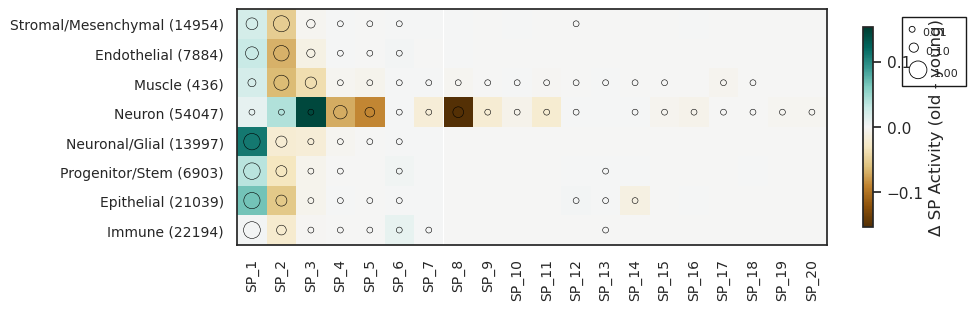

In [88]:
cell_type_col = "broad_cell_type"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/delta_median_old_minus_young_by_medium_cell_type_dot_heatmap.pdf


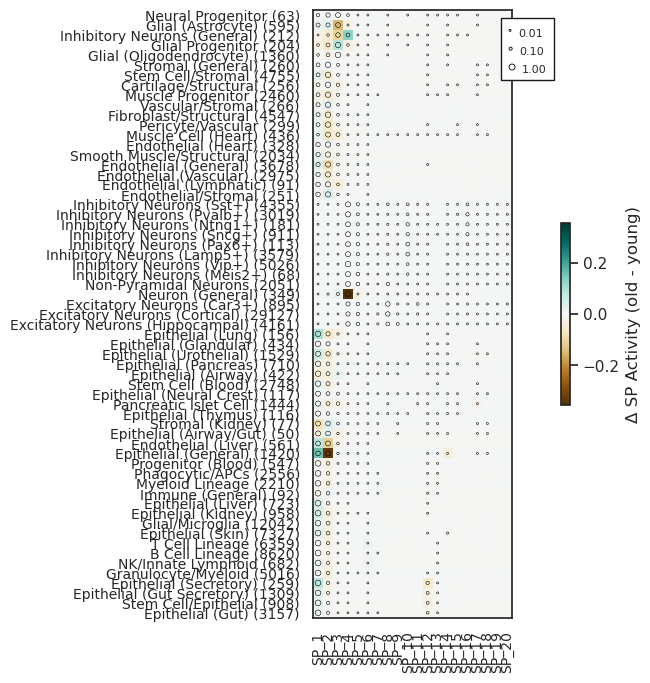

In [89]:
cell_type_col = "medium_cell_type"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/delta_median_old_minus_young_by_tissue_celltype_dot_heatmap.pdf


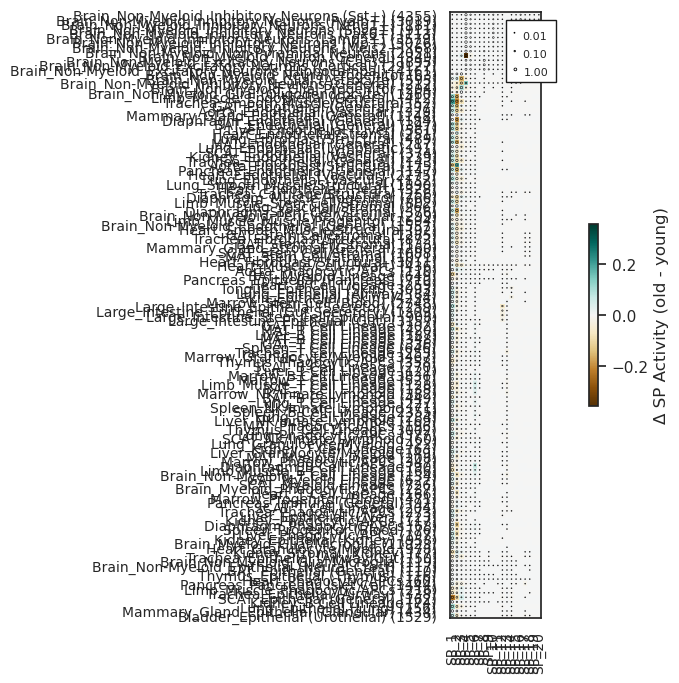

In [90]:
cell_type_col = "tissue_celltype"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

In [91]:
def plot_factor_junction_annotation_counts(final_df, output_path):
    """
    Create a stacked barplot showing the number of significant junctions per factor,
    colored by junction annotation category.
    """
    # Count unique junctions by (factor, annotation)
    counts = (
        final_df.groupby(["factor_idx", "junction_annotation"])["junction_id_index"]
        .nunique()
        .reset_index(name="count")
    )
    # Add factor name column
    counts["factor_name"] = "SP_" + (counts["factor_idx"] +1).astype(str)
    # Pivot to wide format: rows=factor_name, columns=annotation, values=count
    pivot_df = counts.pivot(index="factor_name", columns="junction_annotation", values="count").fillna(0)
    # print table
    print(pivot_df)
    # Sort by total number of junctions
    pivot_df["total"] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values("total", ascending=False)
    pivot_df = pivot_df.drop(columns="total")
    # Plot
    plt.figure(figsize=(5, 3))
    pivot_df.plot(
        kind="bar",
        stacked=True,
        colormap="viridis",  # Or use sns.color_palette("Set2", n_colors=...)
        edgecolor="black"
    )
    plt.xlabel("Splicing Program", fontsize=12)
    plt.ylabel("# of Significant Junctions", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Junction Annotation", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # Save
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

In [92]:
def plot_junction_factor_distribution(final_df, output_path):
    """Create an improved histogram showing distribution of factors per junction"""
    # Get counts of factors/junction
    junc_counts = final_df.groupby("junction_id_index")["factor_idx"].nunique()
    junc_counts_df = pd.DataFrame({"junction_id_index": junc_counts.index, "num_factors": junc_counts.values})
    # Create figure with appropriate size
    plt.figure(figsize=(5, 4))
    # Create histogram with better styling
    ax = sns.histplot(junc_counts_df["num_factors"], bins=range(1, junc_counts_df["num_factors"].max() + 2), 
                     kde=True, color='steelblue', edgecolor='darkblue', alpha=0.7)
    # Add mean line
    mean_factors = junc_counts_df["num_factors"].mean()
    plt.axvline(mean_factors, color='red', linestyle='--', linewidth=2)
    plt.text(mean_factors + 0.2, plt.ylim()[1]*0.9, f'Mean: {mean_factors:.2f}', 
             color='red', fontweight='bold')
    # Add title and labels with better formatting
    plt.xlabel("# of Splicing Programs with Significant \nEffect on Junction", fontsize=12)
    plt.ylabel("# of junctions", fontsize=12)
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3)
    # increase tick font size 
    # Adjust layout
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    # Save figure with higher DPI
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-11-13/2025-11-19/param_id_0/analysis_outputs/differential_splicing_barplot.pdf


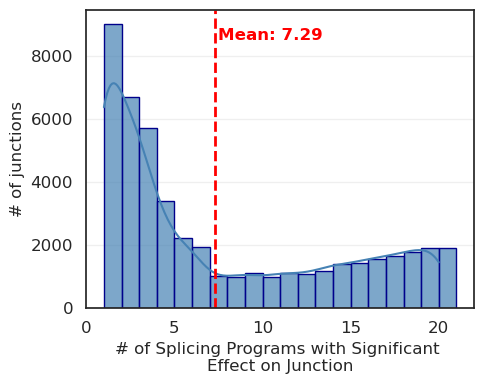

In [93]:
plot_junction_factor_distribution(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_barplot.pdf"))

junction_annotation  3_prime_annotated  5_prime_annotated  Both_SS_annotated  \
factor_name                                                                    
SP_1                               863                542              16778   
SP_10                              432                230              14301   
SP_11                              428                219              13564   
SP_12                              470                243              17339   
SP_13                              446                268              15472   
SP_14                              421                248              17982   
SP_15                              394                258              12116   
SP_16                              447                264              14836   
SP_17                              384                268              12905   
SP_18                              398                259              15795   
SP_19                              408  

<Figure size 500x300 with 0 Axes>

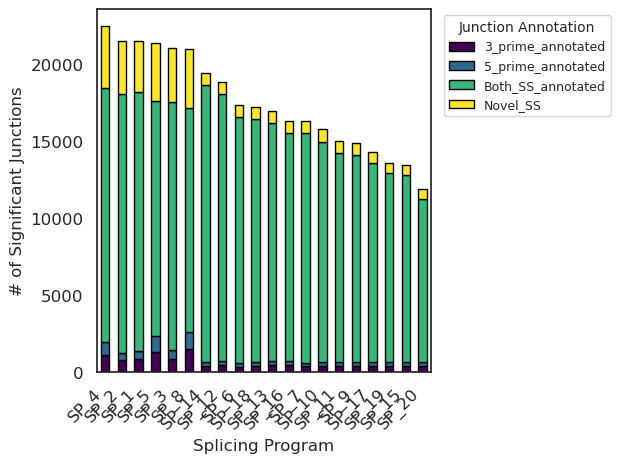

In [94]:
plot_factor_junction_annotation_counts(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_annotation_type_barplot.pdf"))

## Recalculate differential splicing junctions

In [95]:
# Reset junction_id_index column 
psi_samples = leaflet_model["psi_samples"]
splice_adata.var["junction_id_index"] = np.arange(splice_adata.n_vars)
print("\n>> Running analysis functions...")
results = ds.analyze_all_factors_psi(psi_samples, top_junctions=splice_adata.var["junction_id_index"].values, min_effect_size=0.2)
all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    # Append to list
    all_results.append(significance_df)
    print("\n>> Running analysis functions...")

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]
# convert splice_adata.var["junction_id_index"] to dtype int64
splice_adata.var["junction_id_index"] = splice_adata.var["junction_id_index"].astype("int64")



>> Running analysis functions...
Analyzing differential splicing for 20 factors...
Finding DS junctions in factor 0 vs. all others


100%|██████████| 70102/70102 [00:17<00:00, 3984.94it/s]


Found 16278 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 1 vs. all others


100%|██████████| 70102/70102 [00:15<00:00, 4515.10it/s]


Found 21479 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 2 vs. all others


...

Found 16300 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 18 vs. all others


100%|██████████| 70102/70102 [00:15<00:00, 4602.39it/s]


Found 17198 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 19 vs. all others


100%|██████████| 70102/70102 [00:16<00:00, 4255.51it/s]


Found 21362 significant junctions with effect size > 0.2 at FDR < 0.05

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...


In [96]:
# Step 2: Rename and map
final_df = final_df.rename(columns={"factor_idx": "old_factor_idx"})
final_df["factor_idx"] = final_df["old_factor_idx"].map(old_to_new_factor_idx)

In [97]:
# Merge with adata.var using junction_id_index
final_df = final_df.merge(splice_adata.var, on="junction_id_index")

In [98]:
# Create boolean masks for gene types
is_aging_gene = final_df["gene_name"].isin(aging_genes_mouse)
is_rbp_gene = final_df["gene_name"].isin(rbps)

# Initialize junction_label with 'Other'
final_df["junction_label"] = "Other"
final_df.loc[is_rbp_gene, "junction_label"] = "RBP"
final_df.loc[is_aging_gene, "junction_label"] = "Aging"

# Set 'Aging+RBP' if it's both (this will overwrite 'Aging' or 'RBP' if applicable)
final_df.loc[is_aging_gene & is_rbp_gene, "junction_label"] = "Aging+RBP"
print(final_df.junction_label.value_counts())

junction_label
Other        1328040
RBP            37620
Aging          31180
Aging+RBP       5200
Name: count, dtype: int64


In [99]:
final_df = final_df.merge(atse_df, on="junction_id")

In [108]:
final_df[final_df["junction_id"] == "chr10_76892656_76961747_-"]

,old_factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
2281,0,2281,0.058705,0.058705,4.037258e-07,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
72383,1,2281,0.056362,0.056362,7.206138e-07,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
142485,2,2281,0.034956,0.034956,3.143988e-05,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
212587,3,2281,0.039206,0.039206,1.562913e-05,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
282689,4,2281,0.033325,0.033325,2.021656e-05,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
352791,5,2281,0.059001,0.059001,3.930307e-07,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
422893,6,2281,0.056449,0.056449,9.258407e-07,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
492995,7,2281,0.058683,0.058683,4.384114e-07,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
563097,8,2281,-0.992633,0.992633,3.339476e-07,100.0,1.0,0.0,True,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
633199,9,2281,0.052966,0.052966,2.579485e-06,0.0,0.0,1.0,False,0.2,...,0.9912,0.9775,270101,273884,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated


In [102]:
final_df.sort_values(by="abs_effect_size", ascending=False).iloc[0]

old_factor_idx                                                               8
junction_idx                                                              2281
effect_size                                                          -0.992633
abs_effect_size                                                       0.992633
effect_size_var                                                            0.0
num_greater                                                              100.0
prob_greater                                                               1.0
prob_lessoreq                                                              0.0
significant                                                               True
delta                                                                      0.2
psi_factor_mean                                                            0.0
psi_nonfactor_mean                                                    0.992633
fdr_curve                                           

Unique transcripts: {'s4bf0525ca8d7349f:e2707160ad58abc6f', 's4bf0525ca8d7349f:eaf3866e57440be5a', 's7706e1aac6816bf9:eaf4c8a0f7b715a76', 's2d4cdb72d3c868a3:e2707160ad58abc6f', 's1ff9b096c2c8b81e:e855c7119d4c0b6bc', 's5efc22af17e1ca96:e722d62d8831089e9', 's7706e1aac6816bf9:e30d05083b921fcb7', 'sd54713c880f7cd29:e8bcc5deeff361603', 's5efc22af17e1ca96:e8bcc5deeff361603', 'sce2665498bf95c80:e321a1a01e492df8c', 'sce2665498bf95c80:e855c7119d4c0b6bc', 'ENSMUST00000001148.10', 's1ff9b096c2c8b81e:e321a1a01e492df8c', 'sd54713c880f7cd29:e722d62d8831089e9', 's8808c5c801dbd3a8:e55afc6b47a258736', 'se26e015b0bb05501:e55afc6b47a258736'}
Unique transcripts: ['ENSMUST00000001148.10']
Unique transcripts to remove: ['s1ff9b096c2c8b81e:e321a1a01e492df8c', 's1ff9b096c2c8b81e:e855c7119d4c0b6bc', 's2d4cdb72d3c868a3:e2707160ad58abc6f', 's4bf0525ca8d7349f:e2707160ad58abc6f', 's4bf0525ca8d7349f:eaf3866e57440be5a', 's5efc22af17e1ca96:e722d62d8831089e9', 's5efc22af17e1ca96:e8bcc5deeff361603', 's7706e1aac6816bf9:

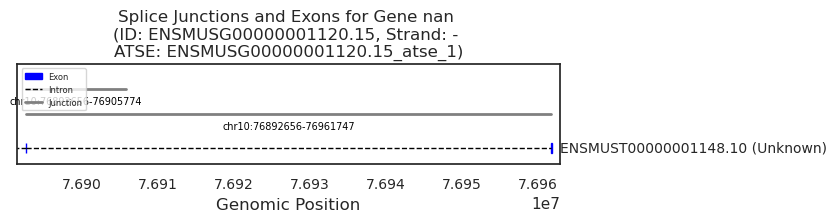

ATSE visualization saved: None


{'junctions':                            event_id                gene_id  gene_name  \
 34095  ENSMUSG00000001120.15_atse_1  ENSMUSG00000001120.15        NaN   
 34096  ENSMUSG00000001120.15_atse_1  ENSMUSG00000001120.15        NaN   
 
        gene_types  num_junctions           event_type chromosome strand  \
 34095         NaN              2  alternative_5_prime      chr10      -   
 34096         NaN              2  alternative_5_prime      chr10      -   
 
        atse_start  atse_end  ...  donor_total_reads  acceptor_total_reads  \
 34095    76892656  76961747  ...             270101                273884   
 34096    76892656  76961747  ...             273884                  4713   
 
        splice_motif  donor_seq  acceptor_seq  position_off_5_prime  \
 34095         GT-AG         GT            AG                   1.0   
 34096         GT-AG         GT            AG                   NaN   
 
       position_off_3_prime junction_annotation usage_ratio  \
 34095             

In [107]:
mouse_event = "ENSMUSG00000001120.15_atse_1"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=7, 
                       trans_height=0.2, 
                  padding=200, show_junc_lines=False, 
                  filter_ensembl_transcripts=True)

In [ ]:
# save final_df to csv 
final_df.to_csv(f"{OUTPUT_DIR}/final_df.tsv.gz", index=False, sep="\t", compression="gzip")
print(f"Saved final_df to {OUTPUT_DIR}/final_df.tsv.gz")

## Check FGFR2 splicing 

In [109]:
splice_adata.var[splice_adata.var["gene_name"] == "FGFR2"]

,index,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,aging_gene,aging_lifespan_effect,aging_longevity_influence,RBP_gene,Aging_gene
72112,91595,chr7_130164123_130167702_-,ENSMUSG00000030849.18_atse_5,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,60996,56278,3423,high,False,NaN,NaN,False,False
72113,91596,chr7_130164215_130167702_-,ENSMUSG00000030849.18_atse_5,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,26243,56279,2009,high,False,NaN,NaN,False,False
72114,91597,chr7_130196374_130198418_-,ENSMUSG00000030849.18_atse_4,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,40250,56280,1527,high,False,NaN,NaN,False,False
72115,91598,chr7_130196374_130199757_-,ENSMUSG00000030849.18_atse_4,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,20039,56281,1539,high,False,NaN,NaN,False,False
72116,91599,chr7_130198563_130200982_-,ENSMUSG00000030849.18_atse_3,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,34157,56282,1384,high,False,NaN,NaN,False,False
72117,91600,chr7_130199905_130200982_-,ENSMUSG00000030849.18_atse_3,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,18344,56283,1458,high,False,NaN,NaN,False,False


In [110]:
splice_adata.layers["denoised_PSI"] = splice_adata.obsm["X_PHI"] @ splice_adata.varm["psi_learned"].T

chr7_130196374_130198418_-


chr7_130196374_130199757_-


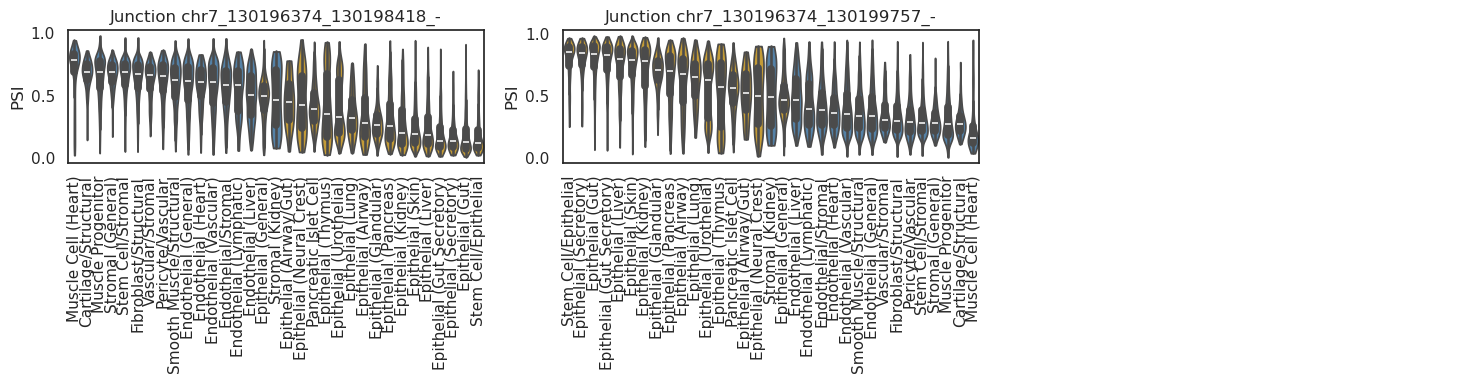

In [115]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- define cell types ---
epi_types = [
    "Epithelial (Airway)",
    "Epithelial (Skin)",
    "Epithelial (General)",
    "Epithelial (Gut)",
    "Stem Cell/Epithelial",
    "Epithelial (Airway/Gut)",
    "Epithelial (Urothelial)",
    "Pancreatic Islet Cell",
    "Epithelial (Kidney)",
    "Epithelial (Liver)",
    "Epithelial (Thymus)",
    "Epithelial (Gut Secretory)",
    "Epithelial (Secretory)",
    "Epithelial (Glandular)",
    "Epithelial (Pancreas)",
    "Epithelial (CNS Lining)",
    "Epithelial (Neural Crest)",
    "Epithelial (Lung)",
    "Neuroendocrine"
]
mes_types = [
    "Endothelial (Vascular)",
    "Muscle Cell (Heart)",
    "Endothelial (General)",
    "Smooth Muscle/Structural",
    "Fibroblast/Structural",
    "Endothelial/Stromal",
    "Muscle Progenitor",
    "Pericyte/Vascular",
    "Stem Cell/Stromal",
    "Vascular/Stromal",
    "Endothelial (Liver)",
    "Stromal (Kidney)",
    "Endothelial (Heart)",
    "Cartilage/Structural",
    "Stromal (General)",
    "Endothelial (Lymphatic)",
    "Endothelial (CNS)",
    "Stromal/Structural",
    "Smooth Muscle/Pericyte"
]
keep_types = epi_types + mes_types
type_colors = {ct: ("goldenrod" if ct in epi_types else "steelblue") for ct in keep_types}

# --- pick ATSE event ---
# NOTE: 'splice_adata' must be loaded in your environment for the following code to run.
event_id = "ENSMUSG00000030849.18_atse_4"

# --- get junctions for this ATSE ---
junc_meta = splice_adata.var.loc[splice_adata.var["event_id"] == event_id]
j_indices = junc_meta["junction_id_index"].astype(int).tolist()

# --- prep cell type info ---
cell_types = splice_adata.obs["medium_cell_type"].astype("category")
mask = cell_types.isin(keep_types)
cell_types = cell_types[mask].cat.remove_unused_categories()

# --- loop through junctions ---
n = len(j_indices)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

for idx, (ax, j) in enumerate(zip(axes.ravel(), j_indices)):
    # get PSI column
    col = splice_adata.layers["denoised_PSI"][:, j]
    # get junction_id for this junction 
    junction_id = splice_adata.var["junction_id"][j]
    print(junction_id)
    psi = col.A1 if hasattr(col, "A1") else col
    psi = pd.Series(psi, index=splice_adata.obs_names)[mask]

    df = pd.DataFrame({"PSI": psi.values, "cell_type": cell_types.values})

    # order cell types by decreasing median PSI for this junction
    order = (
        df.groupby("cell_type", observed=True)["PSI"]
          .median()
          .sort_values(ascending=False)
          .index
          .tolist()
    )

    sns.violinplot(
        data=df, x="cell_type", y="PSI",
        inner="box", cut=0, palette=type_colors, order=order, ax=ax
    )
    ax.set_title(f"Junction {junction_id}")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=90)

# hide empty subplots
for ax in axes.ravel()[n:]:
    ax.axis("off")

plt.tight_layout()
# NOTE: plt.show() will display the figure when run in an interactive environment.
# plt.show()

Unique transcripts: {'s539aaca35d435961:e040fec4c4dff257c', 'sefd2f83a7fea2b97:edc9b4d917a9f1fd2', 's539aaca35d435961:ecc229da486966aef', 'sa9cccdfbfba3f907:e0a16a5e3aa0291cb', 's8c5131ffa20d1353:e0b18985b097fd5c8', 's2565f9afb396020e:e05d011280628c4fd', 's19b51256774b4aa6:edc9b4d917a9f1fd2', 's56e7d4bf52274b06:e040fec4c4dff257c', 's1e6b63fbf1731047:e731468475a7cbef4', 's707ac4764e3753b8:e0a16a5e3aa0291cb', 's6fdf88c959240fb7:ef6eff2359a9bc177', 's6fdf88c959240fb7:e98a0fd275d88297f', 'ENSMUST00000120187.8', 'sdd555720ccfaf808:e0a16a5e3aa0291cb', 'ENSMUST00000117872.7', 'scb5b3a6257137d8b:e0a16a5e3aa0291cb', 'ENSMUST00000122054.7', 's397bfe5d18e99dca:e040fec4c4dff257c', 'sad50cff31c6a2c9f:e731468475a7cbef4', 's575afedc822340d7:edc9b4d917a9f1fd2', 'sad50cff31c6a2c9f:edc9b4d917a9f1fd2', 'sfcf52d27db8cc14e:e9ed5c52f37bd6a05', 'sa083f6dc345a0e18:ecc229da486966aef', 's311a9aefc990c31d:e040fec4c4dff257c', 'sdd1f68fc058fb8f9:e05d011280628c4fd', 'sca51185f6a0d047d:edc9b4d917a9f1fd2', 's397bfe5d

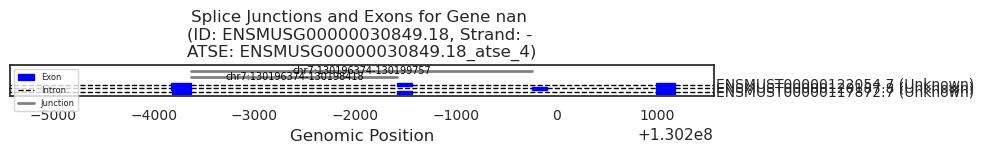

ATSE visualization saved: None


{'junctions':                            event_id                gene_id  gene_name  \
 95147  ENSMUSG00000030849.18_atse_4  ENSMUSG00000030849.18        NaN   
 95148  ENSMUSG00000030849.18_atse_4  ENSMUSG00000030849.18        NaN   
 
        gene_types  num_junctions           event_type chromosome strand  \
 95147         NaN              2  alternative_5_prime       chr7      -   
 95148         NaN              2  alternative_5_prime       chr7      -   
 
        atse_start   atse_end  ...  donor_total_reads  acceptor_total_reads  \
 95147   130196374  130199757  ...              40250                 60440   
 95148   130196374  130199757  ...              60440                 20266   
 
        splice_motif  donor_seq  acceptor_seq  position_off_5_prime  \
 95147         GT-AG         GT            AG                   1.0   
 95148         GT-AG         GT            AG                   1.0   
 
       position_off_3_prime junction_annotation usage_ratio  \
 95147          

In [117]:
mouse_event = "ENSMUSG00000030849.18_atse_4"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=10, 
                       trans_height=0.2, 
                  padding=800, show_junc_lines=False)